## **Preprocessing and Quality Control of DeeplabCut Whisker Tracking Data**
This section describes the preprocessing pipeline applied to DeepLabCut (DLC) whisker tracking outputs, including likelihood-based cleaning, interpolation, smoothing, and subsequent quality control steps to verify the reliability of the processed data prior to whisker frequency analysis. 

#### **1. Introduction to the Whisker Cleaning Pipeline**
In the following step, we will **preprocess and clean whisker tracking data** generated using DLC, a markerless pose estimation framework widely used for tracking animal behavior. The purpose of this preprocessing step is to **prepare the data for subsequent whisker frequency estimation** by transforming the raw DLC output into a **reliable, smooth time-series representation of whisker motion**. 

This preprocessing is performed on the output of the **final DLC model trained on 10 labeled videos (A14, M4, MI16, N10, S17, S8, A12, MO9, N3, and S5)** and represents a **critical intermediate step** between **model-based whisker tracking** and **quantitative whisker frequency analysis**. 

#### **2. Background: Why Clean DLC Whisker Data?**
DLC outputs frame-by-frame tracking data for each labeled bodypart. For each whisker point in each video frame, the model provides:
* **x-coordinate:** horizontal position
* **y-coordinate:** vertical position
* **likelihood:** the model's confidence (between 0 and 1) that the detected point is correct

Although DLC provides high-quality tracking overall, the raw output typically contains:
* Frames with **low likelihood values**, where the model is uncertain about the whisker position
* Small coordinate **jitter or spikes** caused by brief tracking errors
* Short **dropouts** when whiskers are occluded or difficult to detect

If these raw coordinates are used directly, analyses such as whisker frequency estimation may become unreliable. Low-confidence frames can introduce artificial motion, discontinuities, or spurious peaks that do not reflect true whisker behavior. For this reason, a principled cleaning procedure is necessary before any time-series-based analysis. 

#### **3. Overview of the Cleaning Procedure**
The cleaning pipeline that follows will be applied **independently to each whisker point** (e.g., **w1c, w1b, w1c**, etc.) and consists of **four main steps**:

##### **3.1 Loading the DLC H5 output**
Each video's tracking data is stored in an **HDF5 (.h5) file** produced by DLC. These files use a **hierarchical column structure (MultiIndex)**, where:
* **Level 0** corresponds to the **scorer/trained DLC model** used to generate the predictions
* **Level 1** corresponds to the **tracked bodyparts** (individual whisker points)
* **Level 2** contains the associated **coordinates (x, y)** and **confidence values (likelihood)**

This structure allows each **whisker point** to be processed **independently and consistently across frames**, while preserving information about **which model generated the predictions**. 

##### **3.2 Identifying low-confidence frames using likelihood**
For each **whisker point**, frames with a **likelihood below the predefined threshold (0.7)** will be treated as **unreliable**. Importantly, the **likelihood values themselves are not altered**. Instead, they are used as a **quality indicator** to decide whether the corresponding position should be trusted. 

When a frame falls below the threshold:
* The associated **x and y values** are marked as **missing (NaN)**
* The **likelihood value is retained unchanged** for later **quality assessment**

*Example:* If whisker point **w1a** has a likelihood of **0.62 in frame 150**, its **x and y values** in that frame are temporarily removed, while the likelihood **0.62** remains stored in the dataset.

##### **3.3 Interpolating missing whisker positions**
After low-confidence frames have been marked as **missing**, **linear interpolation** is applied along the **time axis (frame order)**. This replaces missing **x and y values** using **neighboring high-confidence frames of the same whisker point**. 

This step ensures that:
* **Whisker trajectories remain continuous in time**
* **Short tracking failures** do not create **gaps or abrupt jumps**
* The **temporal structure of the signal** is preserved

Each whisker point is interpolated **independently**, preventing **information leakage across whiskers**. 

*Example:* If **w1a** is confidently tracked in frames **149** and **151**, but unreliable in frame **150**, the position at frame **150** is estimated as a **linear interpolation** between frames 149 and 151. 

##### **3.4 Smoothing the whisker trajectories**
Following interpolation, a **Savitzky-Golay filter** is applied to the **x and y coordinates**. This filter reduces **small-scale jitter** while preserving the **overall shape and dynamics** of the whisker motion. 

Smoothing is especially important for whisker analyses because:
* **Whisker motion is inherently oscillatory**
* **High-frequency noise** can distort **peak detection**
* **Frequency estimation** is sensitive to **small coordinate errors**

##### **3.5 Saving cleaned data in a flat, analysis-ready format**
The cleaned data for each video will be saved as a **CSV file**, with columns such as:
* **w1a_x, w1a_y, w1a_likelihood**
* **w2b_x, w2b_y, w2b_likelihood**, etc.

This flattened format is easier to inspect, visualize, and use for downstream analyses than the original MultiIndex H5 structure.

#### **4. Why This Step Is Essential Before Whisker Frequency Analysis**
Whisker frequency analysis relies on detecting oscillations, peaks, and periodic structure in whisker trajectories over time. Performing such analyses on uncleaned DLC data can lead to:
* False frequency components caused by noise
* Missed whisker movements during low-confidence frames
* Inconsistent results across videos or animals

By applying this cleaning pipeline beforehand:
* Only **reliable positional information** contributes to the motion signal
* Whisker trajectories are **smooth and continuous**
* Frequency, amplitude, and phase estimates become **more accurate and reproducible**

As a result, this preprocessing step establishes a robust foundation for all subsequent whisker-based analyses. 


In [150]:
# Import libraries and initialize variables
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io
import glob
from scipy.signal import butter, filtfilt, find_peaks, correlate, savgol_filter
from scipy.stats import median_abs_deviation, pearsonr, mannwhitneyu, pointbiserialr
from pathlib import Path
from scipy.interpolate import interp1d
from sklearn.feature_selection import mutual_info_regression
from tabulate import tabulate
from mpl_toolkits.mplot3d import Axes3D

# Modify the paths if required
data_path = r"C:\Users\natal\Documents\Master\Semester4\Biomechanics\Treball\selected_files_2026416_1620\NN48_FOV4_control_220424-MS-2025-11-13\videos" # <- Whiskers videos
FOLDER = Path(r"C:\Users\natal\Documents\Master\Semester4\Biomechanics\Treball\OneDrive_2026-04-23\Movement Traces") # <- Movement traces files
FOLDER_Ca = Path(r"C:\Users\natal\Documents\Master\Semester4\Biomechanics\Treball\selected_files_202652_113922\Output") # <- Calcium data files

video_names = ["A12","A13","A14","A15","M4","MI16","MO9","N10","N11","N1","N2","N3",
               "S17","S18","S5","S6","S7","S8"]


In [151]:
# --- Preprocessing parameters ---
likelihood_threshold = 0.7
smooth_window = 11
smooth_polyorder = 3

def clean_whisker_timeseries(x, y, likelihood, pcutoff=likelihood_threshold,
                             smooth=True, window=smooth_window, polyorder=smooth_polyorder):
    df = pd.DataFrame({"x": x, "y": y, "likelihood": likelihood})
    df.loc[df["likelihood"] < pcutoff, ["x","y"]] = np.nan #Likelihood below threshold set to NaN
    df[["x","y"]] = df[["x","y"]].interpolate(method="linear", limit_direction="both") #Linear interpolation to fill NaN values
    if smooth:
        df["x"] = savgol_filter(df["x"], window_length=window, polyorder=polyorder)
        df["y"] = savgol_filter(df["y"], window_length=window, polyorder=polyorder)
    return df["x"].values, df["y"].values

for video in video_names: #Loop through each video and process each h5 file
    h5_file = os.path.join(data_path, f"{video}DLC_Resnet50_NN48_FOV4_control_220424Nov13shuffle1_snapshot_best-80_filtered.h5")
    if not os.path.exists(h5_file):
        print(f"File not found: {h5_file}, skipping...")
        continue

    df = pd.read_hdf(h5_file) #Load the h5 file into a DataFrame
    scorer_name = df.columns.levels[0][0]
    whisker_points = ["w1a","w1b","w1c","w2a","w2b","w2c","w3a","w3b","w3c"]

    cleaned_df = pd.DataFrame(index=df.index)

    for point in whisker_points:
        x_clean, y_clean = clean_whisker_timeseries(
            df[(scorer_name, point, "x")].values,
            df[(scorer_name, point, "y")].values,
            df[(scorer_name, point, "likelihood")].values
        )
        cleaned_df[f"{point}_x"] = x_clean
        cleaned_df[f"{point}_y"] = y_clean
        cleaned_df[f"{point}_likelihood"] = df[(scorer_name, point, "likelihood")].values

#        # === Preview raw vs cleaned for one whisker (e.g. w1b) (Uncomment if required) ===
#     point = "w1b"

#     raw_df = pd.DataFrame({
#         "x_raw": df[(scorer_name, point, "x")].values,
#         "y_raw": df[(scorer_name, point, "y")].values,
#         "likelihood": df[(scorer_name, point, "likelihood")].values,
#     })

#     cleaned_view = cleaned_df[[f"{point}_x", f"{point}_y", f"{point}_likelihood"]].copy()
#     cleaned_view.columns = ["x_clean", "y_clean", "likelihood_clean"]

#     print(f"\n=== {video} – raw (first 5 rows) ===")
#     print(raw_df.head())

#     print(f"\n=== {video} – cleaned (first 5 rows) ===")
#     print(cleaned_view.head())
#     # === end preview ===

#     cleaned_csv = os.path.join(data_path, f"{video}_cleaned.csv") #Save cleaned data as CSV
#     cleaned_df.to_csv(cleaned_csv, index=False)
#     print(f"Cleaned data saved for video {video} -> {cleaned_csv}")

# print("All videos processed successfully!")


## **Time-Resolved Whisking Frequency Extraction**
**Peak-Valley Cycle-Based Pipeline (100 fps)**

#### **1. General Introduction**
**Rodent whisking** is a highly **rhythmic, sensorimotor behavior** generated by **central pattern generators** in the brainstem and modulated by **sensory input, arousal**, and **behavioral context**. Because whisking frequency can change rapidly - sometimes within **tens of milliseconds** - accurate quantification requires a method that preserves the **temporal structure of individual whisking cycles** (*Hui Article*).

Traditional approaches such as the **Fast Fourier Transform (FFT)** provide frequency estimates averaged over long windows. While useful for global trends, FFT-based methods obscure **rapid transitions** in whisking dynamics and cannot resolve **cycle-by-cycle variability** (*Hui Article*).

To address this limitation, the present pipeline implements a **cycle-resolved whisking frequency estimation method** based on **peak-valley detection** of whisker angular displacement. This approach:
* Identifies **individual whisking cycles** from the whisker's angular trajectory
* Computes **instantaneous frequency** for each cycle
* Preserves **high temporal resolution** (10 ms at 100 fps)
* Produces **physiologically intepretable** frequency estimates

This pipeline is applied to **DeepLabCut (DLC)**-tracked whisker coordinates from mouse **NN48**, which expresses a **neuronal calcium indicator** and a **Gi-coupled DREADD**. The mouse underwent multiple stimulation paradigms:
* **Condition A:** Air puff at 10 s (≈40 s duration)
* **Condition N:** No stimulation (baseline)
* **Condition MI:** Sandpaper moves *in* at 1 s
* **Condition MO:** Sandpaper moves *out* at 1 s
* **Condition S:** Sandpaper remains in contact throughout
* **Condition T:** Stick sweeps whiskers at 10 s

Most sessions last **~2 minutes** (except A). 

##### **Why focus on a single whisker point (w1b)?**
DLC tracks multiple points along each whisker (e.g., w1a, w1b, w1c). For frequency extraction, the goal is to obtain a **clean, high-Signal-to-Noise Ratio (SNR) representation of whisker rotation**.
* **Proximal points (e.g., w1a)** are close to the whisker pad, where **skin deformation** and **micro-movements of the snout** introduce noise.
* **Distal points (e.g., w1c)** experience larger **curvature changes** and **bending artifacts**, especially during object contact.
* **Intermediate points (e.g., w1b)** provide the best compromise:
    * **High SNR**
    * **Minimal curvature artifacts**
    * **Stable tracking** across frames
    * **Strong representation** of rotational whisker motion

Thus, **w1b_x** and **w1b_y** are used as the primary kinematic inputs for **angular conversion**.

#### **2. Import Required Libraries**
This libraries form the **computational backbone** of the whisking-frequency pipeline:
* `os`: Manages **file paths** and **directory navigation**, enabling automated batch processing across multiple video-derived CSV files.
* `numpy` (`np`): Performs fast, **vectorized numerical operations** (operations applied to whole arrays at once). This is crucial for manipulating coordinate arrays, computing angles, filtering signals, and handling large datasets efficiently.
* `pandas` (`pd`): Reads and organizes the **DLC output files** into structured **DataFrames**, making it straightforward to extract whisking coordinates and align data across frames. 
* `matplotlib.pyplot` (`plt`): Used to **plot the filtered whisker angle signal** and **overlay detected whisking cycles**. 
* `scipy.signal`: Provides core **signal-processing tools**:
    * `butter`, `filtfilt` for constructing and applying a **zero-phase Butterworth bandpass filter**, ensuring that only whisking-relevant frequencies are preserved.
    *  `find_peaks` for detecting **peaks or valleys** in the angular displacement signal, which form the basis of **cycle-by-cycle frequency estimation**.
* `scipy.stats.median_abs_deviation`: Computes the **Median Absolute Deviation (MAD)**, a **robust measure of variability** used to set **adaptive prominence thresholds** for peak/valley detection. MAD is preferred over standard deviation because it is far **less sensitive to outliers and tracking noise**, making it ideal for biological signals. 

#### **3. Define analysis parameters**
Here we define **physiologically and technically relevant parameters** used for whisking analysis:
* `FPS = 100`: videos were recorded at **100 frames per second**, giving a **10 ms temporal resolution** that is sufficient to resolve individual whisking cycles. 
* `LOWCUT = 4` Hz, `HIGHCUT = 30` Hz: These values define the **bandpass filter range**, which matches the **typical whisking frequency band** in rodents. Frequencies outside this range are removed because they represent **slow drift** or **high-frequency noise**, not whisking.
* `MIN_FREQ` and `MAX_FREQ`: These bounds ensure that only **physiologically realistic whisking cycles** are kept. Any detected cycle with a frequency below **4 Hz** or above **30 Hz** is likely **noise** or an **artifact** and is therefore excluded.
* `AMPLITUDE_THRESHOLD`: This rejects **tiny fluctuations** that do not reflect real whisker motion.
    * **Amplitude** = the **change in angle** between successive frames (or between peaks and valleys).
    * **Amplitude threshold** = the **minimum angle change** required for a movement to count as a **whisking cycle**.
        * The whisker angle signal naturally fluctuates over time.
            * If the angle change is **smaller** than the threshold, it is likely just **tracking noise or a tiny wobble**.
            * If the angle change is **larger** than the threshold, it is treated as a **genuine whisking movement**.
    * Setting an amplitude threshold ensures that only **biologically meaningful whisker movements** are counted. 

In [152]:
# --- Processing parameters ---
FPS = 100  # video frame rate (frames per second)
LOWCUT = 4 # Loweer bound of whisking frequency (Hz)
HIGHCUT = 30 # Upper bound of whisking frequency (Hz)

MIN_FREQ = 0 # Lower bound for whisking cycles (Hz)
MAX_FREQ = 30 # Physiological upper bound for whisking cycles (Hz)

AMPLITUDE_THRESHOLD = 5  # Minimum angular change (degrees) to accept a cycle

#### **4. Bandpass filter function**
This function applies a **zero-phase Butterworth bandpass filter** to the whisker angle signal:
* Converts **whisker angular displacement signal** into a **whisking-relevant frequency range** (4-30 Hz), removing slow drifts and high frequency noise.
    * *Whisker angular displacement* refers to the rotation of the whisker around its base, measured in degrees, rather than raw x-y positions. It captures the movement of the whisker in a one-dimensional rotational signal.
    * The *whisking-relevant frequency range* (here, 4-30 Hz) corresponds to the physiologically observed oscillation rates of rodent whisking, excluding very slow drifts or rapid noise. 
* Uses `filtfilt` to ensure **no phase shift**, so the timing of peaks and valleys remains accurate.
    * A *phase shift* occurs when filtering delays or shifts the signal in time, which can misalign detected peaks and valleys relative to the original signal.
    * `filtfilt` performs **forward and backward filtering**, effectively canceling phase distortion so the timing of whisking cycles remains exact. 
* The filter **removes slow drifts** (baseline movement) and **high-frequency noise**, which could create spurious cycles.
    * *Slow drifts* might come from small camera movements, body posture changes, or overall slow motion unrelated to whisking.
    * *High frequency noise* can be caused by pixel-level tracking errors, jitter in the camera, or subtle vibrations. 

Bandpass filtering is essential for **accurate peak-valley detection**, as emphasized in the article. By isolating only the physiologically relevant oscillations, the filter ensures that **detected peaks and valleys correspond to real whisking cycles**, not artifacts. The article highlights that this step is critical for obtaining **reliable cycle-by-cycle frequency estimates**. 

In [153]:
def bandpass_filter(signal, fs, lowcut, highcut, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal)

#### **5. Cartesian to angular conversion**
* Converts **x-y whisker coordinates** to a **single angular displacement signal**, simplifying the data into a form suitable for **cycle-by-cycle analysis**. 
    * The raw DLC output provides Cartesian coordinates (`x`, `y`) for each labeled tracked whisker point across all video frames. Each whisker is represented by multiple points along its length (e.g., w1a, w1b, w1c).
    * This step **transforms those 2D positions into a one-dimensional rotational signal**, capturing the whisker's being or swinging motion without needing to track each axis separately. This simplifies subsequent **cycle-by-cycle frequency analysis**.
* `np.arctan2(y, x)`: calculates the angle relative to the whisker base.
    * The **whisker base** is the fixed point where the whisker attaches to the snout. In theory, the most proximal points (w1a, w2a, w3a) could serve as the base.
    * In practice, small movements of the snout or tracking variability mean these points are **not perfectly stable**. Using them directly could introduce noise. Instead, the pipeline **estimates a virtual base by centering the whisker coordinates**, treating the mean position as the origin `(0,0)` for the selected intermediate point `(w1b)`.
    * `np.arctan2(y, x)` calculates the **signal angle** between the line connecting this virtual base to the whisker point and the x-axis. Unlike `arctan(y/x)`, `arctan2` correctly identifies the quadrant, avoiding ambiquity when the whisker swings across axes. 
* `np.unwrap`: prevents sudden jumps at ± 180°.
    * Angular measurements naturally wrap around at ± 180° (or ±π radians). When the whisker crosses this boundary, the raw angle can **jump abruptly** from +180° to -180° (or vice versa).
    * `np.unwrap` corrects these discontinuities by adding or subtracting multiples of 360°, producing a **continuous trajectory** suitable for detecting cycles reliably. 
* Subtracting the mean centers the signal around **0°**.
    * Centering the signal removes the resting or baseline whisker angle.
    * This ensures that **oscillations reflect actual whisker swings** around the baseline rather than being biased by the resting position.
    * Peaks and valleys now represent meaningful excursions for frequency estimation.
* Output is in **degrees**, making it easier to intepret biologically.
    * While `np.arctan2` returns radians, converting to degrees provides a scale easier to intepret for small whisker rotations (e.g., 10° vs. 0.17 radians). 

This step **reduces the 2D motion to 1D angular rotation**, which is the signal used for cycle-by-cycle frequency detection. 

In [154]:
def cart2angle(x, y):
    x = x - np.nanmean(x)
    y = y - np.nanmean(y)
    angle = np.unwrap(np.arctan2(y, x))
    return np.degrees(angle)

#### **6. Peak-valley cycle detection**
This function implements the **core cycle-resolved frequency estimation**:
1. **Median Absolute Deviation (MAD)**
    * Computes the MAD of the angular displacement signal.
    * **Definition:** MAD = $\text{median}(|x_i - \text{median}(x)|)$
    * **Purpose:** MAD is a **robust measure of variability**, less sensitive to outliers than standard deviation. It provides a stable basis for setting a threshold that distinguishes **real whisking cycles** from noise. 
2. **Prominence threshold for valleys**
    * A **valley** is a local minimum in the angular displacement signal, corresponding to a **whisker retraction point**.
    * The **prominence threshold** is set as **1.5 x MAD** to ignore small fluctuations or "wiggles" that do not reflect genuine whisking movement.
3. **Peak-valley detection**
    * Valleys are detected by applying `find_peaks` to the **negative angle signal**, allowing reliable identification of retraction points.
    * Each detected valley marks the transition from one whisking cycle to the next (retraction → protraction → retraction) and provides a **consistent landmark** for measuring cycle duration. 
4. **Cycle-by-cycle frequency calculation**
    * The **frequency of each cycle** is calculated as: $f = \frac{\text{fps}}{\Delta \text{frames}}$
    * Where,
        * *f* = whisking frequency (Hz)
        * **fps** = video frame rate (frames per second, e.g., 100 fps)
        * **Δframes** = number of frames between two **successive valleys**
        * **One valley-to-valley interval equals one full whisking cycle**.
            * A *whisking cycle* is defined as the motion between **two successive valleys (retraction minima)** in the angular displacement signal. One valley-to-valley interval corresponds to **one full whisking cycle**. 
6. **Frequency filtering**
    * Only frequencies within the **physiological range** (4-30 Hz) are retained.
    * Out-of-range vales may be artifacts or noise.

This method avoids FFT averaging and provides **true cycle-level temporal resolution**, allowing rapid changes in whisking dynamics to be captured.. 

In [155]:
def peak_valley_frequency(angle_trace, fps):
    mad = median_abs_deviation(angle_trace, scale='normal')

    prominence = mad * 1.5

    valleys, _ = find_peaks(
        -angle_trace, 
        prominence=prominence
    )
    times = []
    freqs = []
    for i in range(1, len(valleys)):
        delta_frames = valleys[i] - valleys[i - 1]
        if delta_frames <= 0:
            continue

        # One valley-to-valley interval = one full whisking cycle
        freq = fps / delta_frames

        if MIN_FREQ <= freq <= MAX_FREQ:
            times.append(valleys[i])
            freqs.append(freq)

    return np.array(times), np.array(freqs)

#### **7. Amplitude-based artifact rejection**
* Ensures detected whisking cycles are **biomechanically meaningful** by discarding tiny fluctuations that do not reflect real whisker motion.
* Removes **high-frequency noise or tracking errors**, such as small jitters caused by camera movement, body motion, or poor marker localization in DeepLabCut.
* For each detected valley frame, the function calculates the **amplitude of movement** as: Amplitude = $|\theta_i - \theta_{i-1}|$. Where $\theta_i$ is the angular displacement at frame $i$.
* Only valleys where this amplitude exceeds a predefined **threshold** are considered valid whisking cycles.
* This filtering step ensures that only cycles with **meaningful whisker movement** are retained, preventing noise-driven fluctuations from being counted as real cycles. 
* **Amplitude threshold selection:** Threshold choice (e.g., 3 vs. 5 units) balances **sensitivity** (keeping small real cycles) versus **specificity** (removing artifacts). In this pipeline, **5 units is used** as the threshold, effectively removing spurious fluctuations (e.g., airflow, camera jitter, body motion) while preserving genuine whisking cycles for accurate frequency analysis. 


In [156]:
def amplitude_filter(angle_trace, indices, threshold):
    valid = []
    for idx in indices:
        if idx <= 0 or idx >= len(angle_trace):
            valid.append(False)
            continue

        amp = abs(angle_trace[idx] - angle_trace[idx - 1])
        valid.append(amp >= threshold)

    return np.array(valid)

#### **8. Frequency classification**
* Assigns **behavioral labels** to each whisking cycle based on its **instantaneous frequency**.
* Classification bins:
    * **Very Slow:** 0-4 Hz
    * **Slow:** 4-8 Hz
    * **Moderate:** 8-15 Hz
    * **High:** 15-28 Hz
* These ranges reflect **typical physiological whisking frequencies** observed in rodents and provide a meaningful way to categorize whisking intensity.
* Facilitates **downstream analysis**, for example:
    * Quantifying how many cycles fall into each frequency category.
    * Comparing whisking dynamics across animals, sessions, or experimental conditions.
* This step converts raw **numerical frequencies** into **intepretable behavioral states**, making the output more meaningful for neuroscience-focused interpretation.
* Using a discrete labeling system complements the **cycle-by-cycle frequency estimation**, preserving temporal precision while providing a **categorical summary** of whisking behavior. 

In [157]:
def classify_frequency(freqs):
    labels = np.empty(len(freqs), dtype=object)
    labels[(freqs >= 0) & (freqs < 4)] = "very slow"
    labels[(freqs >= 4) & (freqs < 8)] = "slow"
    labels[(freqs >= 8) & (freqs < 15)] = "moderate"
    labels[(freqs >= 15) & (freqs <= 28)] = "high"
    return labels

#### **9. Full Pipeline for a single video**
* Integrates all functions into a **single, reusable pipeline**
    * This function acts as a wrapper that sequentially applies each previously defined processing step. Combining them into one pipeline ensures consistent analysis across videos without manually calling each function. 
* Reads a **cleaned DLC CSV**
* Extracts **x-y coordinates for a specific whisker point (default: w1b)**
    * Using a single intermediate whisker point provides stable tracking and minimizes curvature-related artifacts. The default argument also makes it easy to switch whiskers without modifying the function.
* Converts to angular displacement → bandpass filters the signal → detects cycles → rejects artifacts → classifies frequency
    * This summarizes the full processing flow, transforming raw kinematic data into **cycle-resolved, biologically interpretable whisking metrics**. Each step progressively reduces noise and increases physiological specificity.
* Returns a **DataFrame** with one row per detected whisking cycle
    * Each row corresponds to the **valley marking the end of a whisking cycle**.
    * The **frame** value is the index of that valley (the cycle's endpoint).
    * The **frequency** assigned to that row is the **frequency of the cycle that ended at that valley**. 

Thus function is designed to be called repeatedly, allowing consistent processing across multiple videos while preserving the cycle-resolved structure of whisking analysis. 

In [158]:
# --- EVENT BASED CYCLE OUPUT ---

def process_video_cycles(clean_file, video_name, whisker="w1b"):
    df = pd.read_csv(clean_file)

    # Extract Cartesian coordinates
    x = df[f"{whisker}_x"].values
    y = df[f"{whisker}_y"].values

    # Convert to angular displacement
    angle = cart2angle(x, y)
    
    # Bandpass filter (4–30 Hz)
    angle_filt = bandpass_filter(angle, FPS, LOWCUT, HIGHCUT)
    
    # Peak–valley cycle-based frequency
    times, freqs = peak_valley_frequency(angle_filt, FPS)
    
    # Artifact rejection (wiggle subsequence filtering)
    valid = amplitude_filter(angle_filt, times, AMPLITUDE_THRESHOLD)
    times = times[valid]
    freqs = freqs[valid]

    # Behavioral classification
    labels = classify_frequency(freqs)

    return pd.DataFrame({
        "video": video_name,
        "frame": times,
        "frequency_hz": freqs,
        "category": labels
    })


# #--- Uncomment if you would like to use the function and display the result ---

# import os

# data_path = r"/Users/mayacurry/Desktop/Biomechanics/DIY Project/Whisker Kinematic Data/DLC final model"
# clean_file = os.path.join(data_path, "N10_cleaned.csv")  # exact same naming as cleaning script

# df_event = process_video(clean_file, video_name="N10", whisker="w1b")
# df_event.head(10)

#### **10. Distribution of event-based whisking frequencies**
This histogram visualisation is intended to display shifts from slow to moderate to high whisking frequencies. This visualisation aids to understand the occurrence of passive versus active whisking as the mouse moves through the environment. 

#### **11. Distribution of inferred cycle-based whisking**

This section computes cycle durations (period) from instantaneous frequency (T = 1/f) whisking frequency and then plots the distribution of these cycle-based measures across whisking speed categories for all videos.

The histogram below is a plot including the "very slow" frequency categorisation

Total cycles across all videos: 1713


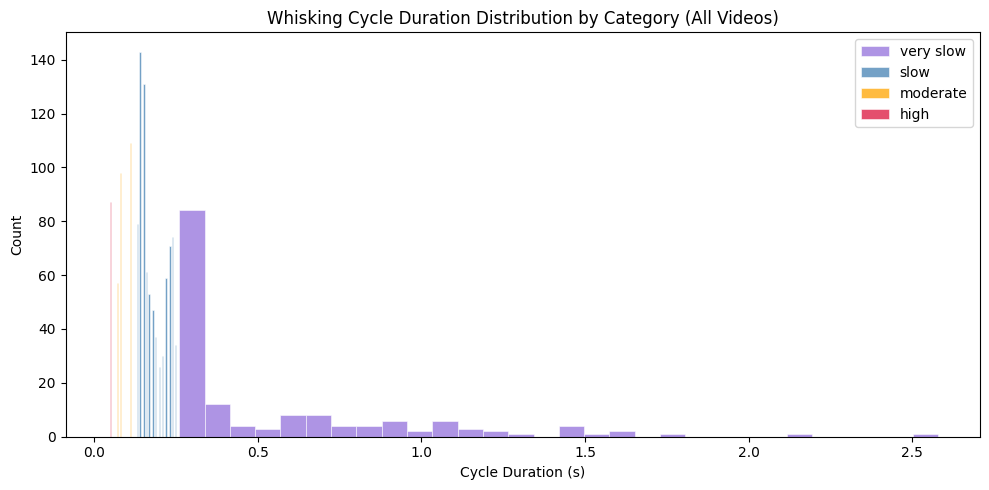

In [159]:
cleaned_folder = data_path
 
video_names = ["A12","A13","A14","A15","M4","MI16","MO9","N10","N11","N1","N2","N3",
               "S17","S18","S5","S6","S7","S8"]
 
all_results = []
for video in video_names:
    clean_file = os.path.join(cleaned_folder, f"{video}_cleaned.csv")
    if not os.path.exists(clean_file):
        print(f"Missing file: {clean_file}")
        continue

    result = process_video_cycles(clean_file, video_name=video, whisker="w1b")
    all_results.append(result)
 
df_whisking = pd.concat(all_results, ignore_index=True)
 
 # Compute cycle duration (period) from frequency
df_whisking["duration (s)"] = np.where(
    df_whisking["frequency_hz"] > 0,
    1 / df_whisking["frequency_hz"],
    np.nan
)

cycle_table = df_whisking[["video", "frame", "category", "frequency_hz", "duration (s)"]].reset_index(drop=True)
print(f"Total cycles across all videos: {len(cycle_table)}")
 
categories = ['very slow', 'slow', 'moderate', 'high']
colors = ['mediumpurple', 'steelblue', 'orange', 'crimson']
 
plt.figure(figsize=(10, 5))
for cat, color in zip(categories, colors):
    data = cycle_table[cycle_table['category'] == cat]['duration (s)'].dropna()
    plt.hist(data, bins=30, color=color, alpha=0.75, label=cat, edgecolor='white', linewidth=0.5)
 
plt.xlabel('Cycle Duration (s)')
plt.ylabel('Count')
plt.title('Whisking Cycle Duration Distribution by Category (All Videos)')
plt.legend()
plt.tight_layout()
plt.show()

The histogram below is a plot reduced in cycle duration (up to 0.25s) to better visualise the left-skewed data of categories where whisking frequency (both passive and active) is observed.

Total cycles across all videos: 1713


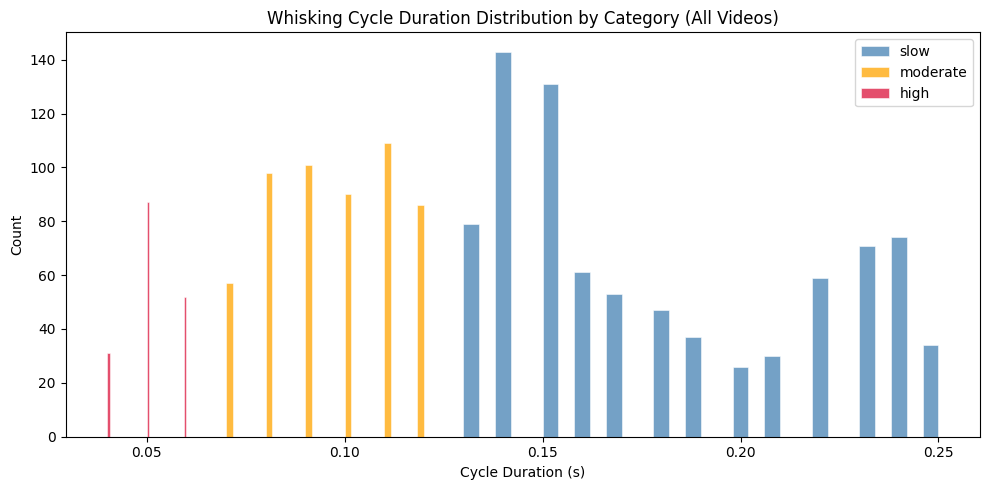

In [160]:
cleaned_folder = data_path
 
video_names = ["A12","A13","A14","A15","M4","MI16","MO9","N10","N11","N1","N2","N3",
               "S17","S18","S5","S6","S7","S8"]
 
all_results = []
for video in video_names:
    clean_file = os.path.join(cleaned_folder, f"{video}_cleaned.csv")
    if not os.path.exists(clean_file):
        print(f"Missing file: {clean_file}")
        continue

    result = process_video_cycles(clean_file, video_name=video, whisker="w1b")
    all_results.append(result)
 
df_whisking = pd.concat(all_results, ignore_index=True)
 
 # Compute cycle duration (period) from frequency
df_whisking["duration (s)"] = np.where(
    df_whisking["frequency_hz"] > 0,
    1 / df_whisking["frequency_hz"],
    np.nan
)

cycle_table = df_whisking[["video", "frame", "category", "frequency_hz", "duration (s)"]].reset_index(drop=True)
print(f"Total cycles across all videos: {len(cycle_table)}")
 
categories = ['slow', 'moderate', 'high']
colors = ['steelblue', 'orange', 'crimson']
 
plt.figure(figsize=(10, 5))
for cat, color in zip(categories, colors):
    data = cycle_table[cycle_table['category'] == cat]['duration (s)'].dropna()
    plt.hist(data, bins=30, color=color, alpha=0.75, label=cat, edgecolor='white', linewidth=0.5)
 
plt.xlabel('Cycle Duration (s)')
plt.ylabel('Count')
plt.title('Whisking Cycle Duration Distribution by Category (All Videos)')
plt.legend()
plt.tight_layout()
plt.show()

#### **12. Transition from event-based cycles to frame-aligned time series**

The initial analysis represents whisking as an event-based signal. Frequencies are estimated at peak-valley cycles and summarised as one value per detected cycle, with N = 1713 cycles total. This representation is well suited for characterising the distribution of whisking periods, but it is not directly compatible with other frame-indexed signals such as binary movement or calcium fluorescence traces that were sampled continuously over time.

To enable overlay and joint analysis with frame-wise signals, the cycle-based output is transformed into a frame-aligned time series through assinging each cycle's frequency and category to the adjacent frames between consecutive cycle events. The output is a piecewise-constant, frame-resolved frequency trace that can be overlayed with the movement and calcium data on a common time axis. 

In [161]:
# --- FRAME ALIGNED TIME SERIES OUTPUT ---
def process_video_frame_aligned(clean_file, video_name, whisker="w1b"):
    df = pd.read_csv(clean_file)

    x = df[f"{whisker}_x"].values
    y = df[f"{whisker}_y"].values
    angle = cart2angle(x, y)
    angle_filt = bandpass_filter(angle, FPS, LOWCUT, HIGHCUT)

    times, freqs = peak_valley_frequency(angle_filt, FPS)
    valid = amplitude_filter(angle_filt, times, AMPLITUDE_THRESHOLD)
    times = times[valid]
    freqs = freqs[valid]
    labels = classify_frequency(freqs)

    all_frames = np.arange(len(angle))
    result = pd.DataFrame({
        "video": video_name,
        "frame": all_frames,
        "frequency_hz": 0.0,
        "category": "non-whisking"
    })

    for i in range(len(times) - 1):
        start = int(times[i])
        stop = int(times[i + 1])
        result.loc[start:stop, "frequency_hz"] = freqs[i]
        result.loc[start:stop, "category"] = labels[i]

    return result

#### **13. Distribution of frame-aligned whisking**

This section estimates the instantaneous frequency at each video, aligned to the original time series, thus the plot displays the time-resolved whisking frequencies across categories for all videos.

Total frames across all videos (frame aligned output): 187915
Rows in df_whisking: 187915
Unique frames per video (example N10): 12269
Min/max frame for N10: 0 12268


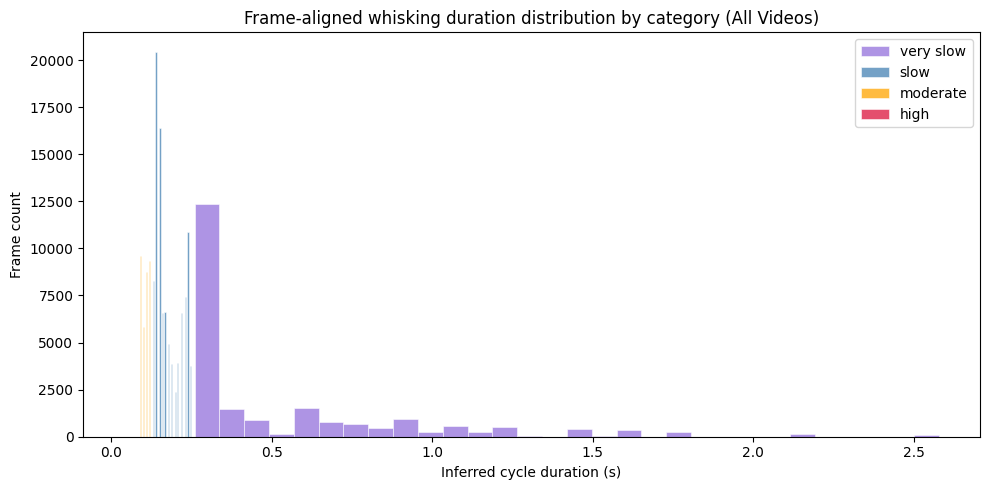

In [162]:
cleaned_folder = data_path
 
video_names = ["A12","A13","A14","A15","M4","MI16","MO9","N10","N11","N1","N2","N3",
               "S17","S18","S5","S6","S7","S8"]
 
all_results = []
for video in video_names:
    clean_file = os.path.join(cleaned_folder, f"{video}_cleaned.csv")
    if not os.path.exists(clean_file):
        print(f"Missing file: {clean_file}")
        continue

    result = process_video_frame_aligned(clean_file, video_name=video, whisker="w1b")
    all_results.append(result)
 
df_whisking = pd.concat(all_results, ignore_index=True)
 
 # Compute cycle duration (period) from frequency
df_whisking["duration (s)"] = np.where(
    df_whisking["frequency_hz"] > 0,
    1 / df_whisking["frequency_hz"],
    np.nan
)

frame_table = df_whisking[["video", "frame", "category", "frequency_hz", "duration (s)"]].reset_index(drop=True)
print(f"Total frames across all videos (frame aligned output): {len(frame_table)}")

categories = ['very slow', 'slow', 'moderate', 'high']
colors = ['mediumpurple', 'steelblue', 'orange', 'crimson']

#Display frame alignment in dataframe for sanity check
print("Rows in df_whisking:", len(df_whisking))
print("Unique frames per video (example N10):",
      df_whisking[df_whisking["video"] == "N10"]["frame"].nunique())
print("Min/max frame for N10:",
      df_whisking[df_whisking["video"] == "N10"]["frame"].min(),
      df_whisking[df_whisking["video"] == "N10"]["frame"].max())
 
plt.figure(figsize=(10, 5))
for cat, color in zip(categories, colors):
    data = frame_table[frame_table['category'] == cat]['duration (s)'].dropna()
    plt.hist(data, bins=30, color=color, alpha=0.75, label=cat, edgecolor='white', linewidth=0.5)
 
plt.xlabel('Inferred cycle duration (s)')
plt.ylabel('Frame count')
plt.title('Frame-aligned whisking duration distribution by category (All Videos)')
plt.legend()
plt.tight_layout()
plt.show()

Histogram without including the "very slow" categorisation.

Total frames across all videos (frame aligned output): 187915
Rows in df_whisking: 187915
Unique frames per video (example N10): 12269
Min/max frame for N10: 0 12268


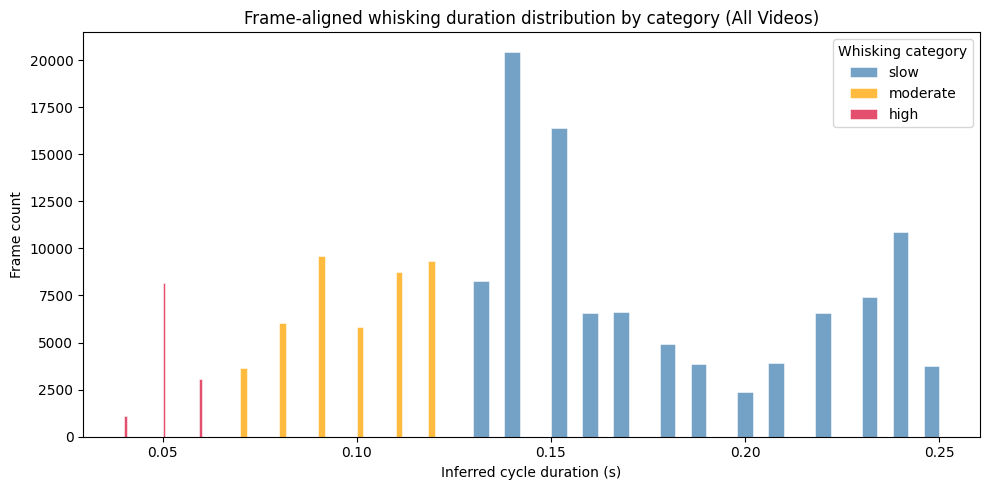

In [163]:
cleaned_folder = data_path
 
video_names = ["A12","A13","A14","A15","M4","MI16","MO9","N10","N11","N1","N2","N3",
               "S17","S18","S5","S6","S7","S8"]
 
all_results = []
for video in video_names:
    clean_file = os.path.join(cleaned_folder, f"{video}_cleaned.csv")
    if not os.path.exists(clean_file):
        print(f"Missing file: {clean_file}")
        continue

    result = process_video_frame_aligned(clean_file, video_name=video, whisker="w1b")
    all_results.append(result)
 
df_whisking = pd.concat(all_results, ignore_index=True)
 
 # Compute cycle duration (period) from frequency
df_whisking["duration (s)"] = np.where(
    df_whisking["frequency_hz"] > 0,
    1 / df_whisking["frequency_hz"],
    np.nan
)

frame_table = df_whisking[["video", "frame", "category", "frequency_hz", "duration (s)"]].reset_index(drop=True)
print(f"Total frames across all videos (frame aligned output): {len(frame_table)}")

categories = ['slow', 'moderate', 'high']
colors = ['steelblue', 'orange', 'crimson']

#Display frame alignment in dataframe for sanity check
print("Rows in df_whisking:", len(df_whisking))
print("Unique frames per video (example N10):",
      df_whisking[df_whisking["video"] == "N10"]["frame"].nunique())
print("Min/max frame for N10:",
      df_whisking[df_whisking["video"] == "N10"]["frame"].min(),
      df_whisking[df_whisking["video"] == "N10"]["frame"].max())
 
plt.figure(figsize=(10, 5))
for cat, color in zip(categories, colors):
    data = frame_table[frame_table['category'] == cat]['duration (s)'].dropna()
    plt.hist(data, bins=30, color=color, alpha=0.75, label=cat, edgecolor='white', linewidth=0.5)
 
plt.xlabel('Inferred cycle duration (s)')
plt.ylabel('Frame count')
plt.title('Frame-aligned whisking duration distribution by category (All Videos)')
plt.legend(title="Whisking category")
plt.tight_layout()
plt.show()

#### **14. Example: single video analysis and output intepretation (A12)**
* Processes a single video (`A12`)
* Prints:
    * The full table of detected whisking cycles
    * Summary statistics of cycle-resolved whisking frequency
    * Counts of cycles in each frequency category

Each row in the output corresponds to **the valley marking the end of a whisking cycle**, not to every video frame. A whisking cycle is defined as the motion from one whisker retraction (valley) to the next. The **frame** value is the index of the **second valley** in that valley-to-valley interval (i.e., the cycle's endpoint). The **frequency** assigned to that row is the **frequency of the cycle that ended at that valley**, computed from the number of frames between this valley and the previous one.

**Output intepretation:**
* **Detailed table intepretation:**
    * The `frame` **column** indicates the video frame at which the whisking cycle is registrered.
        * This frame corresponds to the **valley marking the end of that cycle** (i.e., the second valley in the valley-to-valley interval).
    * The `frequency_hz` column gives the **cycle-resolved whisking frequency**, computed as: $f = \frac{\text{fps}}{\Delta \text{frames}}$.
        * Where $\Delta$frames is the number of frames between two successive valleys.
    * Examples from the output:
        * At frame **170**, the whisker completed a cycle at **8.33 Hz**, classified as **moderate**.
        * At frame **1211**, the whisker completed a cycle at **25 Hz**, classified as **high**.
    * The `category` column assigns a behavioral label based on frequency:
        * **slow:** 4-8 Hz
        * **moderate:** 8-15 Hz
        * **high:** 15-28 Hz
* **Cycle count: 36 cycles detected**
    * A total of **36 whisking cycles** were identified in this video after filtering, peak-valley detection, and amplitude-based artifact rejection.
    * Frames without clear whisking cycles are intentionally excluded, ensuring only high-confidence cycles are analyzed.
* **Frequency summary**
    * The mean frequency (~9 Hz) and range (4-25 Hz) reflect a mixture of **slow, moderate**, and **high-frequency** whisking.
    * The maximum frequency (25 Hz) falls within the upper range of typical rodent whisking dynamics.
* **Category counts**
    * The distribution shows **predominantly slow whisking**, with moderate-frequency cycles occuring regularly and several high-frequency bouts.
    * This pattern is consistent with typical whisking dynamics, where slow cycles dominate and faster cycles occur intermittently, either as part of exploratory behavior or in response to external stimuli such as whisker contacts or airflow.

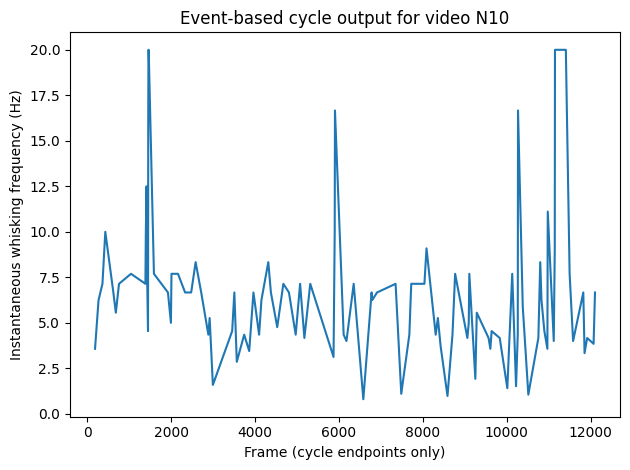

In [164]:
# --- Plot the event-based cycle output ---
df_event = process_video_cycles(clean_file, video_name="N10", whisker="w1b")
plt.figure()
plt.plot(df_event["frame"], df_event["frequency_hz"])
plt.xlabel("Frame (cycle endpoints only)")
plt.ylabel("Instantaneous whisking frequency (Hz)")
plt.title(f"Event-based cycle output for video N10")
plt.tight_layout()

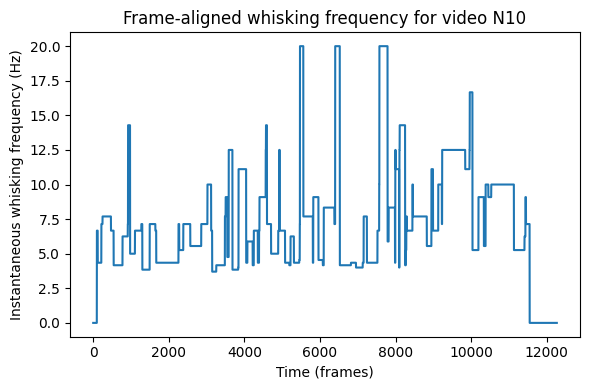

In [165]:
# Plot the frame-aligned time series output
cleaned_folder = data_path  # Adjust if your cleaned CSVs are in a different folder
clean_file = os.path.join(cleaned_folder, "N10_cleaned.csv")
result = process_video_frame_aligned(clean_file, video_name = "N10", whisker="w1b")


# Time in frames vs instantaneous whisking frequency

Time_f = np.arange(len(result["frequency_hz"]))
Freq   = result["frequency_hz"].to_numpy()        

plt.figure(figsize=(6, 4))
plt.plot(Time_f, Freq)
plt.xlabel("Time (frames)")
plt.ylabel("Instantaneous whisking frequency (Hz)")
plt.title(f"Frame-aligned whisking frequency for video N10")
plt.tight_layout()

#print(result["frequency_hz"].describe())
#print(result["category"].value_counts())

#### **15. Whisking epoch duration analysis**

Here consecutive whisking frames from the frame-aligned whisking output are grouped with the same frequency category into behavioural epochs. Then the duration (s) of each epoch was computed and a histogram plot coloured by epoch category is used to visualise the whisking duration.

In [166]:
# --- Create the epoch table function to summarize the frame-aligned output into epochs of whisking categories ---
def compute_epoch_table(cleaned_folder, whisker="w1b", fps=FPS):
    all_epochs = []

    for clean_file in sorted(glob.glob(os.path.join(cleaned_folder, "*_cleaned.csv"))):
        video_name = os.path.basename(clean_file).replace("_cleaned.csv", "")
        result = process_video_cycles(clean_file, video_name=video_name, whisker=whisker)

        whisking = result[result["frequency_hz"] > 0].copy().reset_index(drop=True)
        if whisking.empty:
            continue

        whisking["block"] = (whisking["category"] != whisking["category"].shift()).cumsum()
        epochs = (
            whisking.groupby(["block", "category"], sort=False)
            .size()
            .reset_index(name="n_frames")
        )
        epochs["duration_s"] = epochs["n_frames"] / fps
        epochs["video"] = video_name
        all_epochs.append(epochs)

    if not all_epochs:
        print("No whisking data found.")
        return pd.DataFrame()

    # Build and return the combined dataframe
    combined = pd.concat(all_epochs, ignore_index=True)
    return combined

In [167]:
cleaned_folder = data_path
epoch_df = compute_epoch_table(cleaned_folder, whisker="w1b", fps=FPS) # Build a combined epoch dataFrame

print(epoch_df.shape)
print (epoch_df.head()) 
longest = epoch_df.nlargest(10, "duration_s")
display(longest)

(927, 5)
   block  category  n_frames  duration_s video
0      1  moderate         2        0.02   A12
1      2      slow         5        0.05   A12
2      3  moderate         1        0.01   A12
3      4      slow         1        0.01   A12
4      5  moderate         1        0.01   A12


,block,category,n_frames,duration_s,video
254,5,slow,11,0.11,N10
743,20,slow,11,0.11,S6
82,16,moderate,10,0.10,M4
304,3,slow,10,0.10,N11
462,41,slow,10,0.10,N3
26,3,slow,9,0.09,A13
68,2,moderate,9,0.09,M4
151,11,moderate,9,0.09,MI16
386,11,slow,9,0.09,N2
528,62,moderate,9,0.09,S17


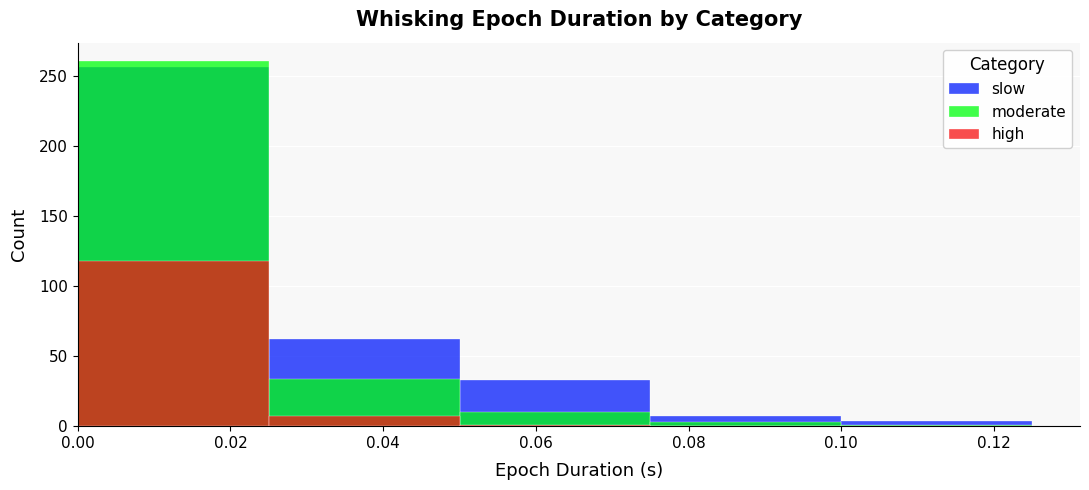

In [168]:
def plot_epoch_duration_histogram_all(cleaned_folder, whisker="w1b", fps=FPS, bin_width=0.025):
    CATEGORY_COLORS = {
        "very slow": "#7b2d8b",
        "slow":      "#031cfc",
        "moderate":  "#00ff0d",
        "high":      "#f71313",
    }
    CATEGORY_ORDER = ["slow", "moderate", "high"]

    all_epochs = []

    for clean_file in sorted(glob.glob(os.path.join(cleaned_folder, "*_cleaned.csv"))):
        result = process_video_cycles(clean_file, video_name=video, whisker=whisker)
        whisking = result[result["frequency_hz"] > 0].copy().reset_index(drop=True)
        if whisking.empty:
            continue
        whisking["block"] = (whisking["category"] != whisking["category"].shift()).cumsum()
        epochs = (
            whisking.groupby(["block", "category"], sort=False)
            .size()
            .reset_index(name="n_frames")
        )
        epochs["duration_s"] = epochs["n_frames"] / fps
        all_epochs.append(epochs)

    if not all_epochs:
        print("No whisking data found.")
        return

    combined = pd.concat(all_epochs, ignore_index=True)
    present = [c for c in CATEGORY_ORDER if c in combined["category"].values]
    bins = np.arange(0, combined["duration_s"].max() + bin_width, bin_width)

    fig, ax = plt.subplots(figsize=(11, 5))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("#f8f8f8")
    ax.grid(axis="y", color="white", linewidth=0.8, zorder=0)

    for cat in present:
        durs = combined.loc[combined["category"] == cat, "duration_s"].values
        ax.hist(durs, bins=bins, alpha=0.75, label=cat,
                color=CATEGORY_COLORS[cat], edgecolor="white", linewidth=0.3, zorder=2)

    ax.set_xlabel("Epoch Duration (s)", fontsize=13, labelpad=8)
    ax.set_ylabel("Count", fontsize=13, labelpad=8)
    ax.set_title("Whisking Epoch Duration by Category", fontsize=15, fontweight="bold", pad=12)
    ax.tick_params(labelsize=11)
    ax.set_xlim(left=0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(title="Category", fontsize=11, title_fontsize=12,
              framealpha=0.9, edgecolor="#cccccc")

    plt.tight_layout()
    display(fig)
    plt.close(fig)

cleaned_folder = data_path
plot_epoch_duration_histogram_all(cleaned_folder)

Reduced x-axis to zoom in on physiologically relevant categories for analysis.

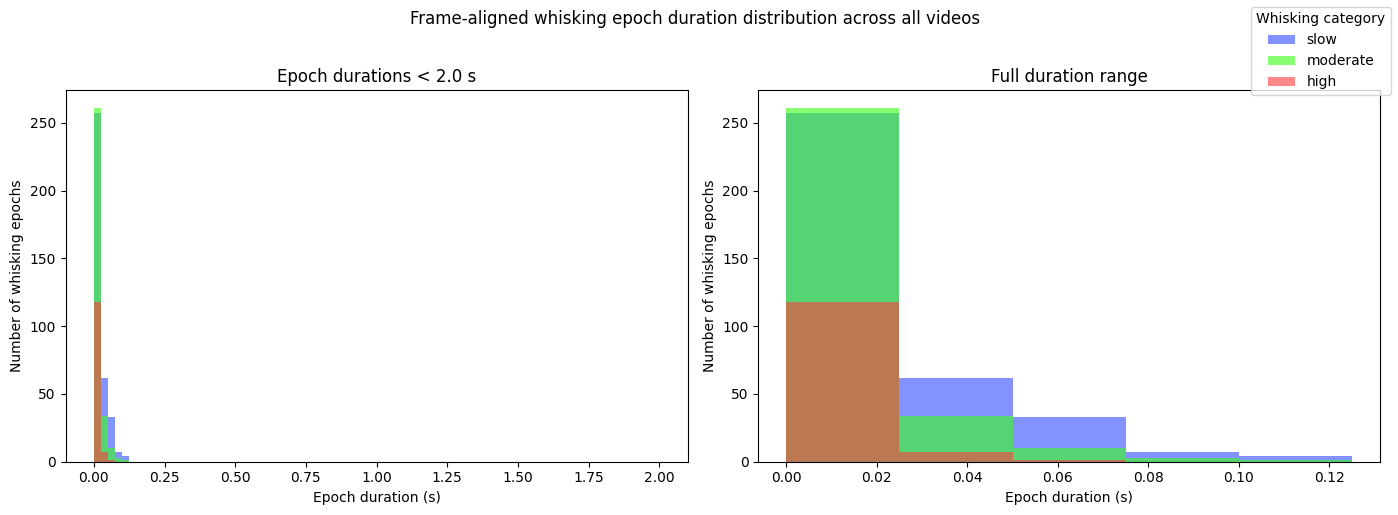

In [169]:
def plot_epoch_duration_histogram_all(cleaned_folder, whisker="w1b", fps=FPS, bin_width=0.025, zoom_max=2.0):
    CATEGORY_COLORS = {
         "slow":      "#2f4bff",
        "moderate":  "#39ff14",
        "high":      "#ff3b3b",
    }
    CATEGORY_ORDER = ["slow", "moderate", "high"]

    all_epochs = []

    for clean_file in sorted(glob.glob(os.path.join(cleaned_folder, "*_cleaned.csv"))):
        video_name = os.path.basename(clean_file).replace("_cleaned.csv", "")
        result = process_video_cycles(clean_file, video_name=video_name, whisker=whisker)

        whisking = result[result["frequency_hz"] > 0].copy().reset_index(drop=True)
        if whisking.empty:
            continue

        whisking["block"] = (whisking["category"] != whisking["category"].shift()).cumsum()
        epochs = (
            whisking.groupby(["block", "category"], sort=False)
            .size()
            .reset_index(name="n_frames")
        )
        epochs["duration_s"] = epochs["n_frames"] / fps
        all_epochs.append(epochs)

    combined = pd.concat(all_epochs, ignore_index=True)
    present = [c for c in CATEGORY_ORDER if c in combined["category"].values]

    zoomed = combined[combined["duration_s"] < zoom_max]
    tail = combined[combined["duration_s"] >= zoom_max]

    bins_zoom = np.arange(0, zoom_max + bin_width, bin_width)
    bins_full = np.arange(0, combined["duration_s"].max() + bin_width, bin_width)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    # Left panel: zoomed in
    for cat in present:
        durs = zoomed.loc[zoomed["category"] == cat, "duration_s"].values
        axes[0].hist(durs, bins=bins_zoom, alpha=0.6, label=cat, color=CATEGORY_COLORS[cat])

    axes[0].set_title(f"Epoch durations < {zoom_max} s")
    axes[0].set_xlabel("Epoch duration (s)")
    axes[0].set_ylabel("Number of whisking epochs")

    # Right panel: full range or tail
    for cat in present:
        durs = combined.loc[combined["category"] == cat, "duration_s"].values
        axes[1].hist(durs, bins=bins_full, alpha=0.6, label=cat, color=CATEGORY_COLORS[cat])

    axes[1].set_title("Full duration range")
    axes[1].set_xlabel("Epoch duration (s)")
    axes[1].set_ylabel("Number of whisking epochs")

    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, title="Whisking category", loc="upper right")
    fig.suptitle("Frame-aligned whisking epoch duration distribution across all videos", y=1.02)
    plt.tight_layout()
    plt.show()
cleaned_folder = data_path
plot_epoch_duration_histogram_all(cleaned_folder)


**Step-plot of whisking category over time**
*    Time series of a behavioural state and frequency over a trial

In [170]:
def process_video_whisking_only(clean_file, whisker="w1b"):
    df = pd.read_csv(clean_file)
 
    # Extract Cartesian coordinates
    x = df[f"{whisker}_x"].values
    y = df[f"{whisker}_y"].values
 
    # Convert to angular displacement
    angle = cart2angle(x, y)
 
    # Bandpass filter (4–30 Hz)
    angle_filt = bandpass_filter(angle, FPS, LOWCUT, HIGHCUT)
 
    # Peak–valley cycle-based frequency
    times, freqs = peak_valley_frequency(angle_filt, FPS)
    # Artifact rejection (wiggle subsequence filtering)
    valid = amplitude_filter(angle_filt, times, AMPLITUDE_THRESHOLD)
    times = times[valid]
    freqs = freqs[valid]

    time_complete = np.arange(0, times[-1] + 1)

    # Initialize frequency vector
    freq_complete = np.zeros_like(time_complete, dtype=float)

    # Fill in the frequencies keeping the value until the next change
    for i in range(len(times) - 1):
        inici = times[i - 1]
        final = times[i]

        freq_complete[inici:final] = freqs[i]

    # Last section
    freq_complete[times[-1]:] = freqs[-1]
        
    # Behavioral classification
    labels = classify_frequency(freq_complete)
 
    return pd.DataFrame({
        "frame": time_complete,
        "frequency_hz": freq_complete,
        "category": labels
    })
    

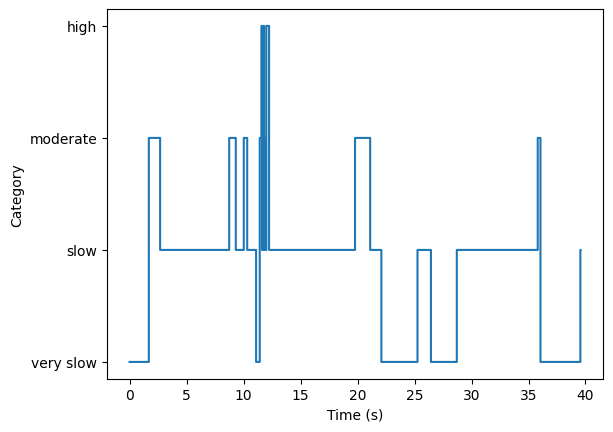

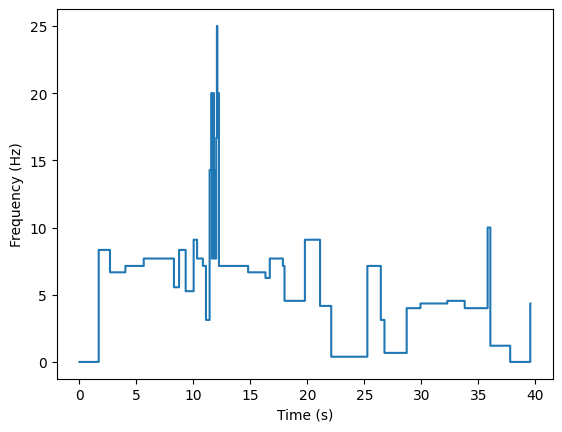

In [171]:
clean_file = os.path.join(cleaned_folder, "A12_cleaned.csv")

result = process_video_whisking_only(clean_file, whisker="w1b")


# Desired order
order = ["very slow", "slow", "moderate", "high"]

# Convert categories to numbers
mapping = {cat: i for i, cat in enumerate(order)}

y = result["category"].map(mapping)

# Plot CATEGORIES
plt.step(result["frame"]/100, y, where='pre')

# Plot labels
plt.yticks(range(len(order)), order)

plt.xlabel("Time (s)")
plt.ylabel("Category")

plt.show()

# Plot FREQUENCIES
plt.step(result["frame"]/100, result["frequency_hz"], where='pre')

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")

plt.show()


**Step-plot of whisking frequency over time**
*    Time series of frequency over all videos

We have found 18 files

Processing: A12_cleaned


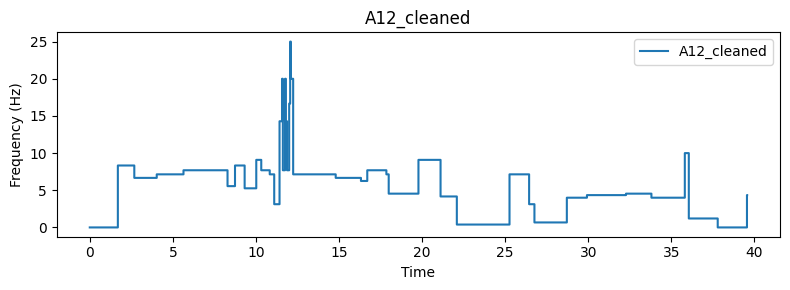

Processing: A13_cleaned


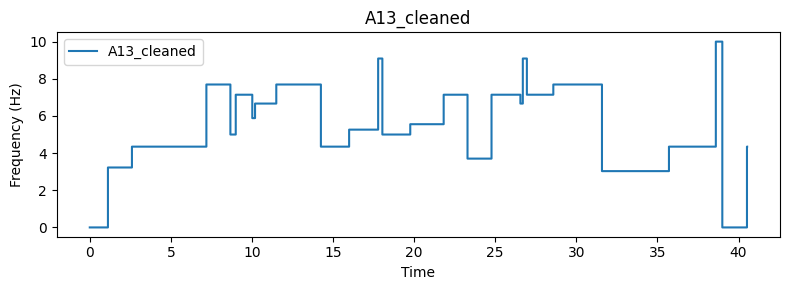

Processing: A14_cleaned


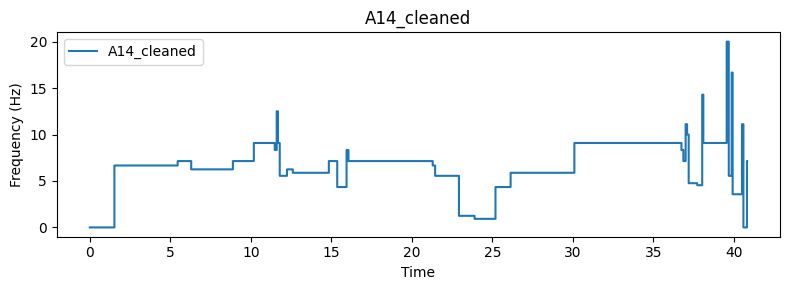

Processing: A15_cleaned


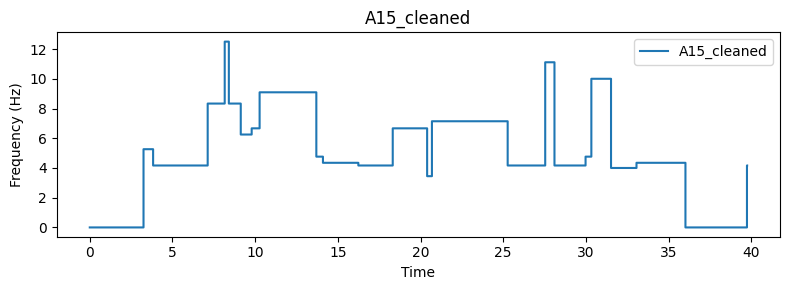

Processing: M4_cleaned


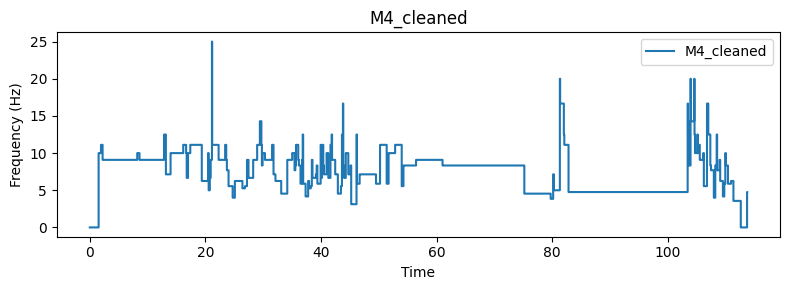

Processing: MI16_cleaned


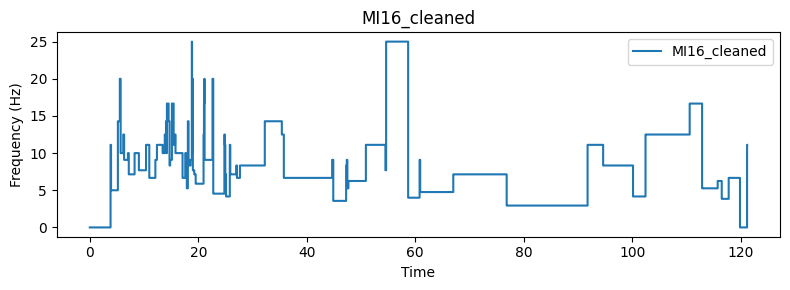

Processing: MO9_cleaned


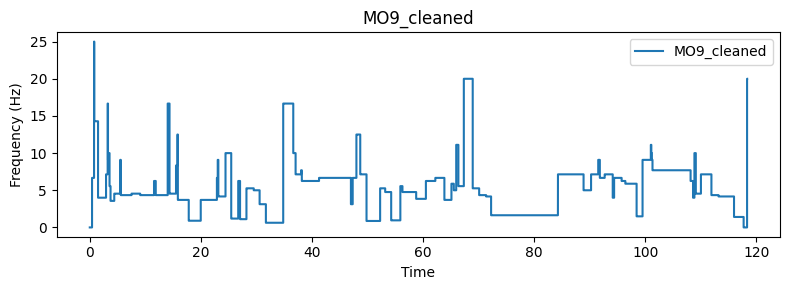

Processing: N10_cleaned


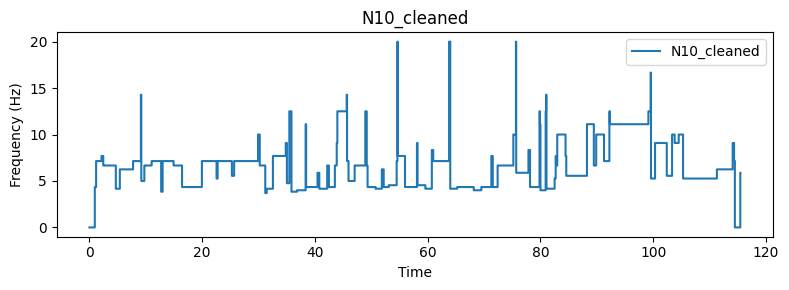

Processing: N11_cleaned


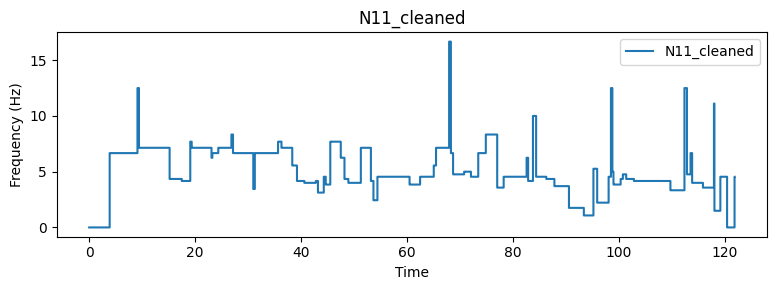

Processing: N1_cleaned


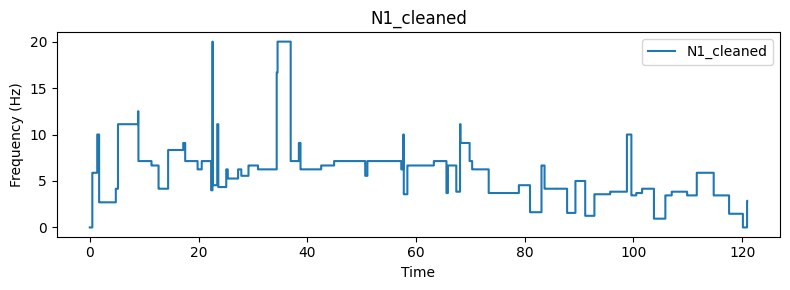

Processing: N2_cleaned


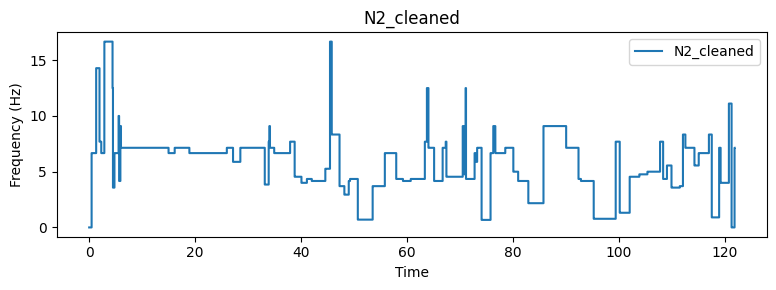

Processing: N3_cleaned


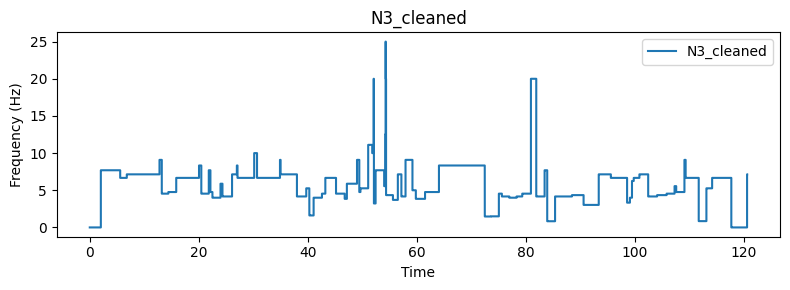

Processing: S17_cleaned


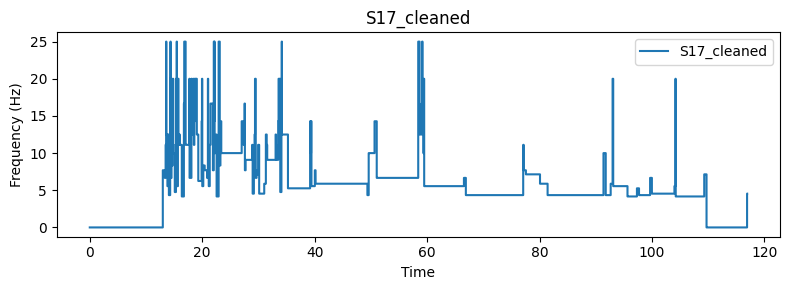

Processing: S18_cleaned


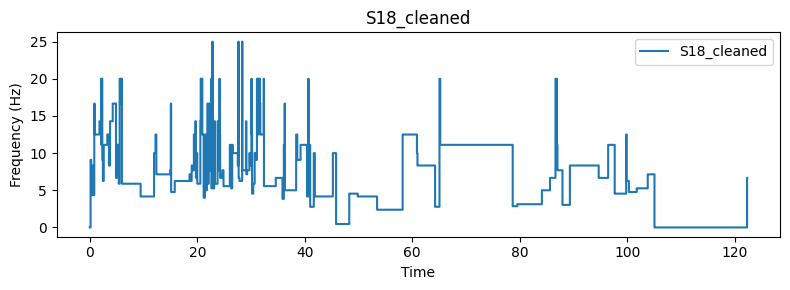

Processing: S5_cleaned


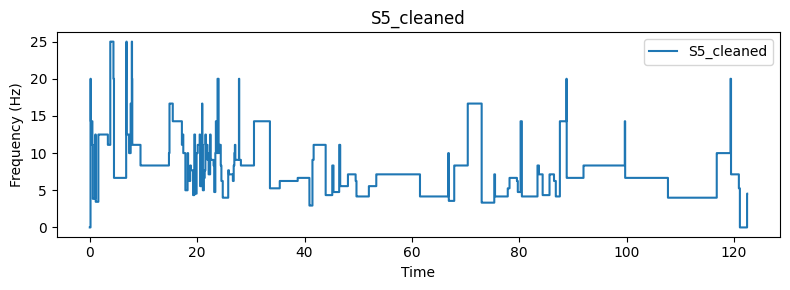

Processing: S6_cleaned


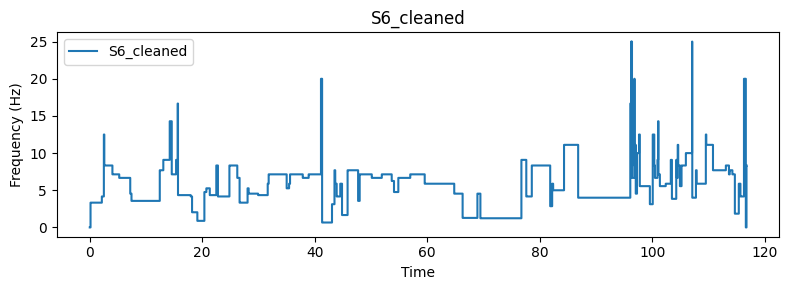

Processing: S7_cleaned


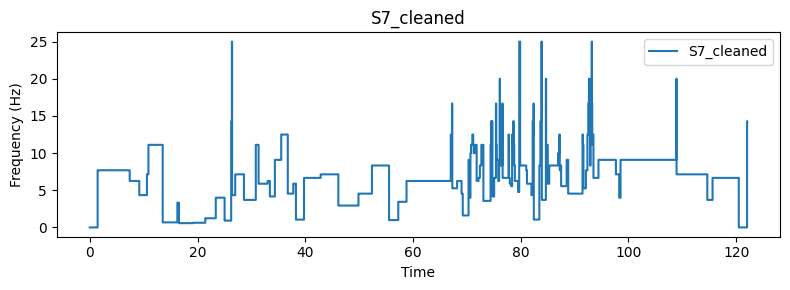

Processing: S8_cleaned


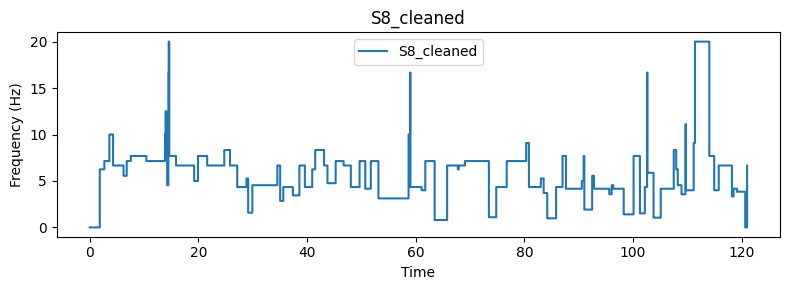

In [172]:
def process_all_cleaned(cleaned_folder):

    # Search all the files *_cleaned.csv
    csv_files = glob.glob(os.path.join(cleaned_folder, "*_cleaned.csv"))

    if not csv_files:
        print("No *_cleaned.csv files found")
        return

    print(f"We have found {len(csv_files)} files\n")

    for file in csv_files:
        print(f"Processing: {os.path.splitext(os.path.basename(file))[0]}")

        # Process every file
        result = process_video_whisking_only(str(file), whisker="w1b")
        Freq = result['frequency_hz']
        Time_f = result["frame"]/FPS

        # Plot
        plt.figure(figsize=(8, 3))
        plt.step(Time_f, Freq, label=os.path.splitext(os.path.basename(file))[0], where='pre')

        plt.xlabel("Time")
        plt.ylabel("Frequency (Hz)")
        plt.title(os.path.splitext(os.path.basename(file))[0])
        plt.legend()

        plt.tight_layout()
        plt.show()
        
process_all_cleaned(cleaned_folder)

**Event based frequency distribution per every video**

In [173]:
def process_video(clean_file, whisker="w1b"):
    df = pd.read_csv(clean_file)
 
    x = df[f"{whisker}_x"].values
    y = df[f"{whisker}_y"].values
    angle = cart2angle(x, y)
    angle_filt = bandpass_filter(angle, FPS, LOWCUT, HIGHCUT)
 
    times, freqs = peak_valley_frequency(angle_filt, FPS)
 
    valid = amplitude_filter(angle_filt, times, AMPLITUDE_THRESHOLD)
    times = times[valid]
    freqs = freqs[valid]

    labels = classify_frequency(freqs)

    # Build full frame list, default everything to non-whisking
    all_frames = np.arange(len(angle))
    result = pd.DataFrame({"frame": all_frames, "frequency_hz": 0.0, "category": "non-whisking"})
 

    # Overwrite detected frames with their actual frequency and category
    for i, f in enumerate(times):
        result.loc[result["frame"] == f, "frequency_hz"] = freqs[i]
        result.loc[result["frame"] == f, "category"] = labels[i]
 
    return result

We have found 18 files

Processing: A12_cleaned


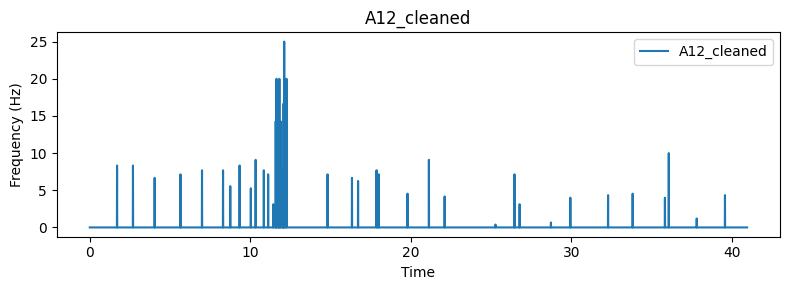

Processing: A13_cleaned


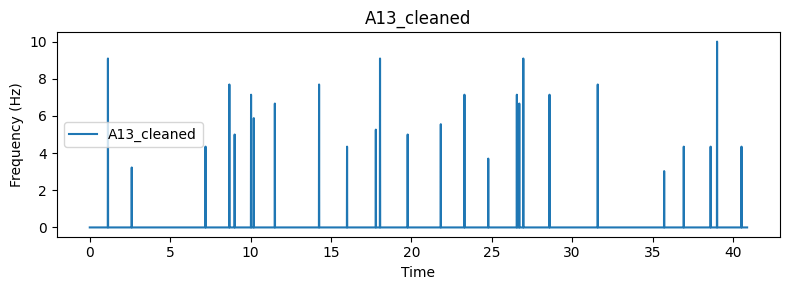

Processing: A14_cleaned


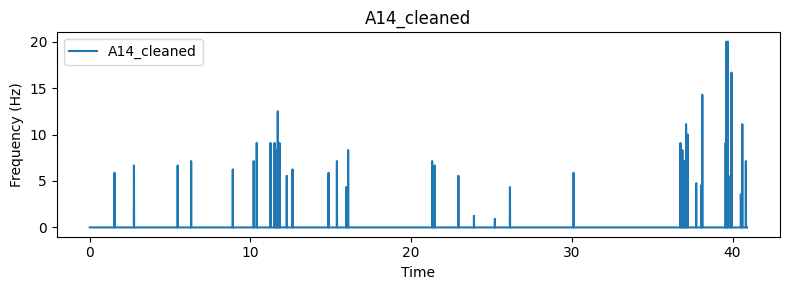

Processing: A15_cleaned


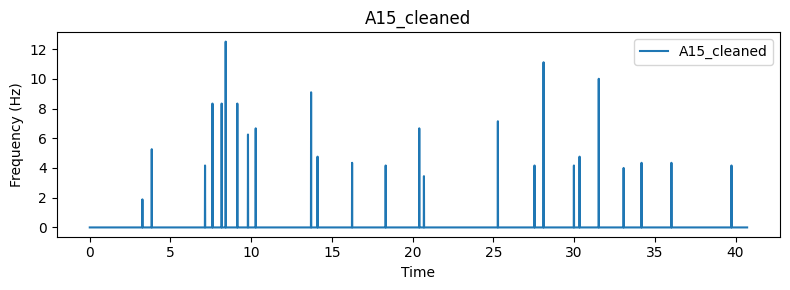

Processing: M4_cleaned


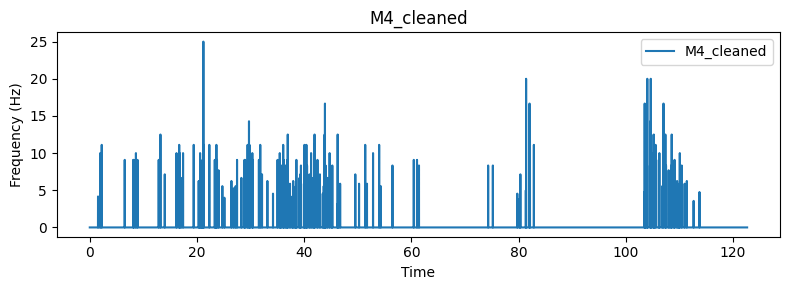

Processing: MI16_cleaned


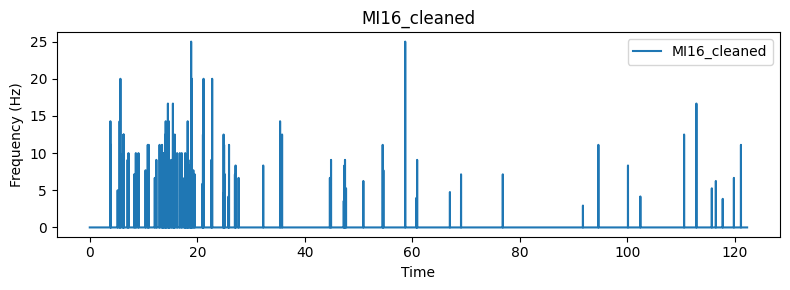

Processing: MO9_cleaned


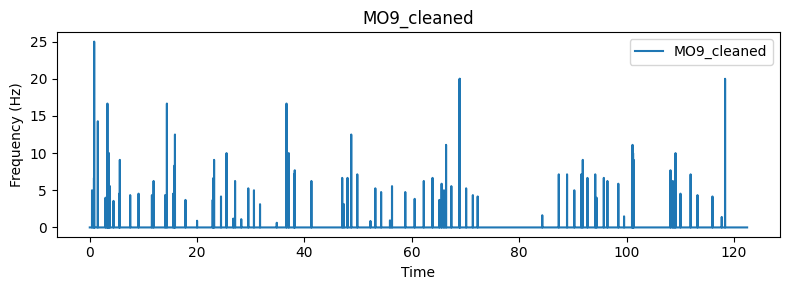

Processing: N10_cleaned


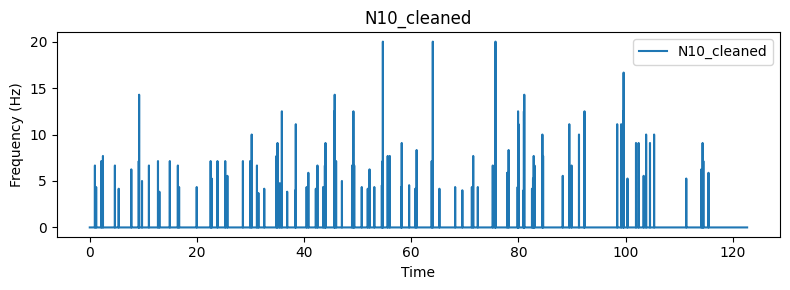

Processing: N11_cleaned


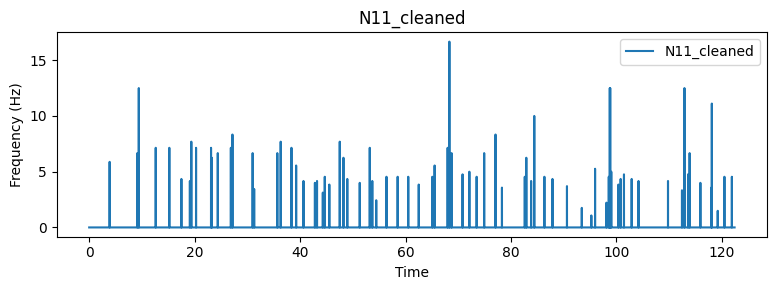

Processing: N1_cleaned


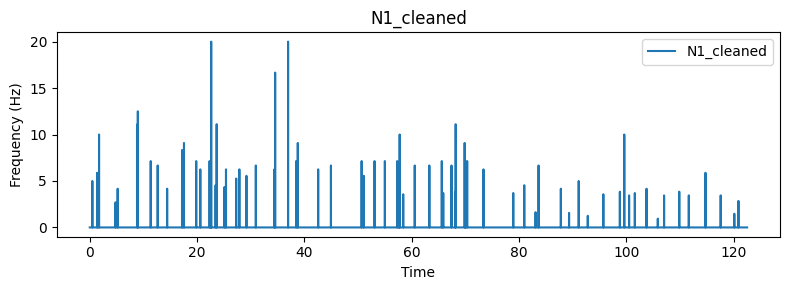

Processing: N2_cleaned


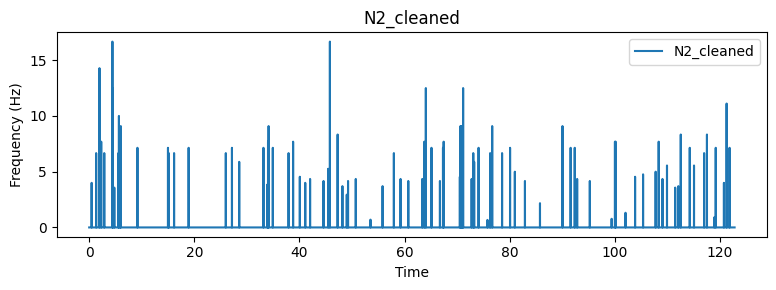

Processing: N3_cleaned


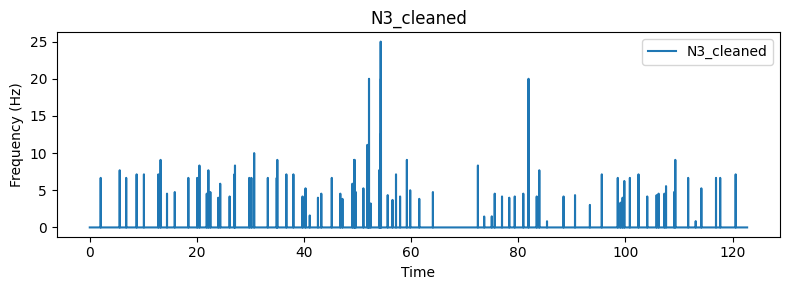

Processing: S17_cleaned


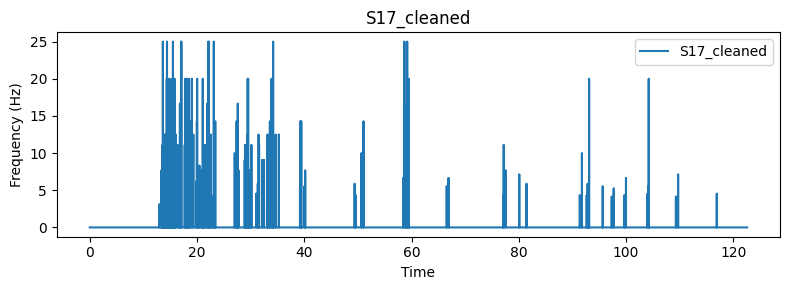

Processing: S18_cleaned


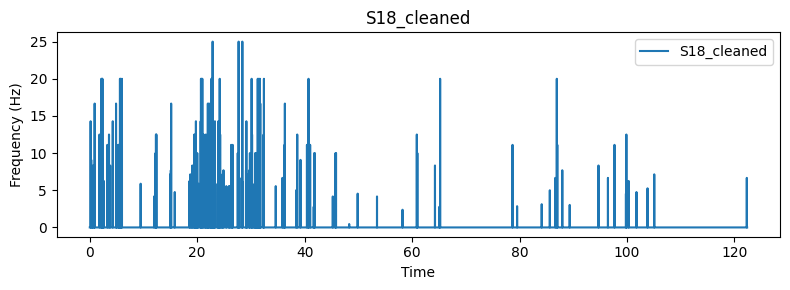

Processing: S5_cleaned


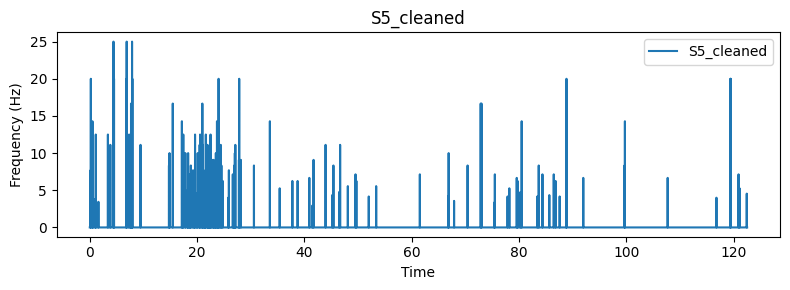

Processing: S6_cleaned


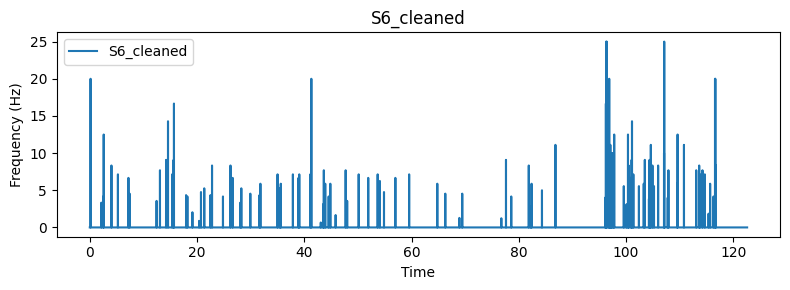

Processing: S7_cleaned


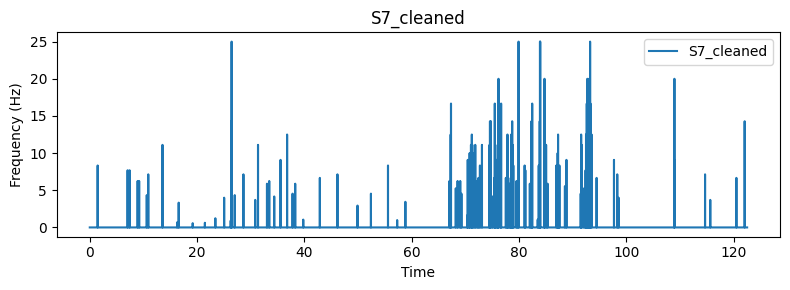

Processing: S8_cleaned


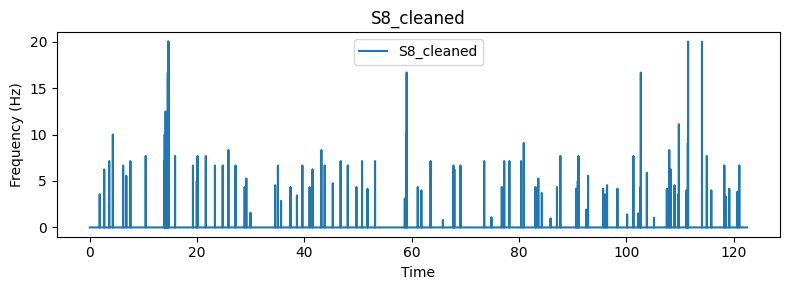

In [174]:
def process_all_cleaned(cleaned_folder):

    # Search all the files *_cleaned.csv
    csv_files = glob.glob(os.path.join(cleaned_folder, "*_cleaned.csv"))

    if not csv_files:
        print("No *_cleaned.csv files found")
        return

    print(f"We have found {len(csv_files)} files\n")

    for file in csv_files:
        print(f"Processing: {os.path.splitext(os.path.basename(file))[0]}")

        # Process every file
        result = process_video(str(file), whisker="w1b")
        Freq = result['frequency_hz'].to_numpy()
        Time_f = np.arange(len(Freq))

        # Plot
        plt.figure(figsize=(8, 3))
        plt.plot(Time_f/100, Freq, label=os.path.splitext(os.path.basename(file))[0])

        plt.xlabel("Time")
        plt.ylabel("Frequency (Hz)")
        plt.title(os.path.splitext(os.path.basename(file))[0])
        plt.legend()

        plt.tight_layout()
        plt.show()
        
process_all_cleaned(cleaned_folder)

### **16. These functions oversample movement signal to aling it in time with the whisking frequency signal, splits frequencies by movement state, and computes:**
*    Point-biserial correlation and p-value
*    Rank-biserial effect size (from Mann-Whitney U)
*    Mean frequency during movement vs no movement
*    Mutual information between movement and frequency
*    Cross-correlation and lag (in seconds) of maximum association
##### It also generates a box-whiskers plot of Frequency vs Movement for each video as well as a final one including all of them.

In [175]:
#Align movement and frequency vectors, compute statistics, and return a dictionary with results
def get_stats_dict(subject_id, movement, frequency): 
    min_len = min(len(movement), len(frequency))
    m = movement[:min_len]
    f = frequency[:min_len]

#Ensure vectors have the same length and separate frequencies based on movement
    freq_move = f[m == 1]
    freq_no_move = f[m == 0]

    #Result structure
    res = {
        "ID": subject_id,
        "Corr_Biserial": np.nan,
        "P_Value": np.nan,
        "Effect_Size": np.nan,
        "Mean_Freq_Move": np.nan,
        "Mean_Freq_Stop": np.nan,
        "Mutual_Info": np.nan,
        "Best_Lag_s": np.nan,
        "Max_CCF": np.nan
    }
    if len(np.unique(m)) > 1 and len(freq_move) > 0 and len(freq_no_move) > 0:
        corr, p_val = pointbiserialr(m, f)
        u_stat, p_mw = mannwhitneyu(freq_move, freq_no_move, alternative='two-sided')
        
        n_m = len(freq_move)
        n_nm = len(freq_no_move)
        rank_biserial = 1 - (2 * u_stat) / (n_m * n_nm)

        # Mutual Information (MI)
        # Solve non lineal relation. 
        mi = mutual_info_regression(m.reshape(-1, 1), f)[0]

        # Cross-Correlation (CCF)
        # Normalise to find the time lag in which the association is maximal
        m_norm = (m - np.mean(m)) / (np.std(m) * len(m))
        f_norm = (f - np.mean(f)) / np.std(f)
        ccf = correlate(m_norm, f_norm, mode='same')
        
        # Find the maximum correlation point
        lags = np.arange(-len(ccf)//2, len(ccf)//2)
        idx_max = np.argmax(np.abs(ccf))
        best_lag_frames = lags[idx_max]
        best_lag_seconds = best_lag_frames / FPS
        
        res.update({
            "Corr_Biserial": round(corr, 3),
            "P_Value": p_val,
            "Effect_Size": round(abs(rank_biserial), 3),
            "Mean_Freq_Move": round(np.mean(freq_move), 2),
            "Mean_Freq_Stop": round(np.mean(freq_no_move), 2),
            "Mutual_Info": round(mi, 3),
            "Best_Lag_s": round(best_lag_seconds, 3),
            "Max_CCF": round(ccf[idx_max], 3)
        })
    
    return res

def style_table(df):
    return df.style.format({'P_Value': '{:.2e}', 
                            'Corr_Biserial': '{:.3f}', 
                            'Effect_Size': '{:.3f}'}) \
                   .set_caption("Statistics Summary: Movement vs Whisking") \
                   .set_table_styles([{'selector': 'th', 'props': [('background-color', "#534c4c")]}])
 


In [176]:
def analyze_movement_frequency(freq, movement, time=None, fs=100):
    """
    Analise movement segments (movement == 1) and compute
    the derivative of the frequency for every movement.

    Parameters
    ----------
    freq : array-like
        Frequency vector.
    movement : array-like
        Binary vector (0 and 1) indicating movement.
    time : array-like, optional
        Time vector. If not provided, it will be generated from the fs.
    fs : float
        Sampling frequency in Hz (default = 100).

    Returns
    -------
    durations : list
        Duration of every movement in seconds.
    mean_slopes : list
        Mean slope of the frequency derivative for every movement.
    """

    freq = np.asarray(freq)
    movement = np.asarray(movement)

    # Analogic frequency for binary movement:
    freq0 = freq[movement == 0]
    freq1 = freq[movement == 1]

    if time is None:
        time = np.arange(len(freq)) / fs
    else:
        time = np.asarray(time)

    # --- DERIVATIVE ---
    # derivative of the frequency regarding time
    d_freq = np.gradient(freq, time)

    # --- FIND SEGMENTS OF MOVEMENT ---
    # changes 0->1 and 1->0
    changes = np.diff(movement.astype(int))

    starts = np.where(changes == 1)[0] + 1
    ends = np.where(changes == -1)[0] + 1

    # Special case if starts with movement
    if movement[0] == 1:
        starts = np.insert(starts, 0, 0)

    # Special case if ends with movement
    if movement[-1] == 1:
        ends = np.append(ends, len(movement))

    durations = []
    mean_slopes = []

    # --- ANALISE EVERY MOVEMENT ---
    for start, end in zip(starts, ends):

        # duration of the movement
        duration = time[end - 1] - time[start]

        # derivative in the movement
        slope_values = d_freq[start:end]

        # mean slope value
        mean_slope = np.mean(slope_values)

        durations.append(duration)
        mean_slopes.append(mean_slope)

    # --- PLOT SLOPE ---
    plt.figure(figsize=(8, 6))

    plt.scatter(durations, mean_slopes)

    plt.xlabel("Movement duration (s)")
    plt.ylabel("Mean derivative of the frequency")
    plt.title("Movement duration vs Slope of the frequency")

    plt.grid(True)
    plt.show()
    
    # --- BOXPLOT ---
    plt.boxplot([freq0, freq1], tick_labels=[0, 1])
    plt.xlabel('Movement')
    plt.ylabel('Frequency (Hz)')
    plt.title('Box-and-whisker plot: Movement vs Frequency')

    plt.show()
    
    

    return durations, mean_slopes, freq0, freq1

Found 18 .mat files

Processing: A12
✔ A12 → A12_cleaned.csv


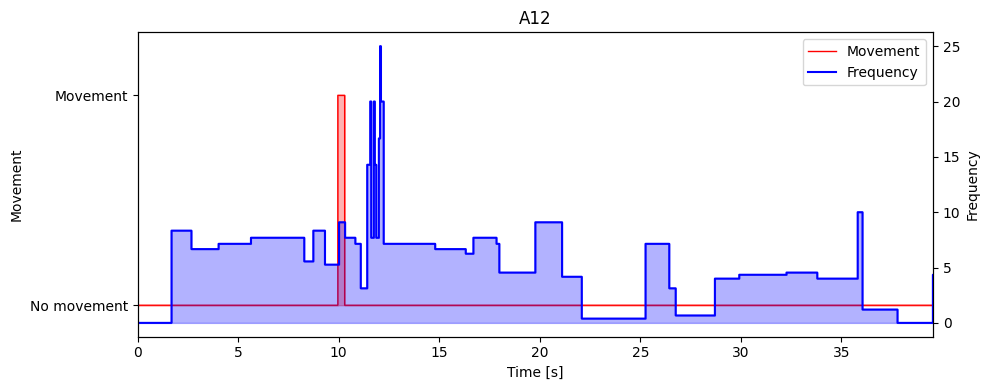

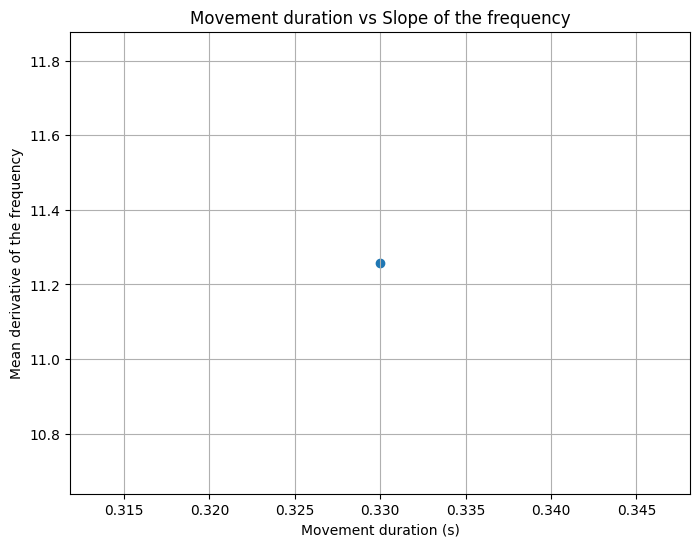

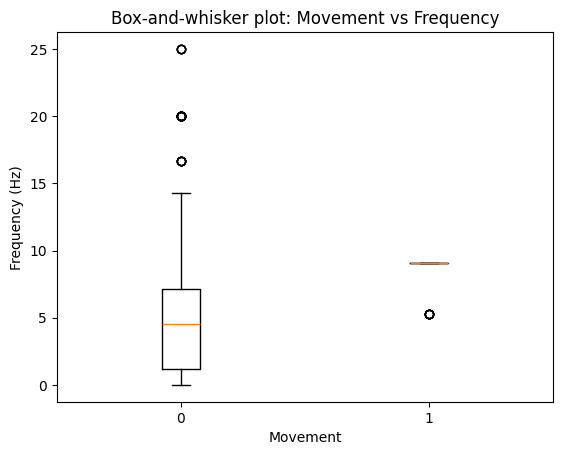

Processing: A13
✔ A13 → A13_cleaned.csv


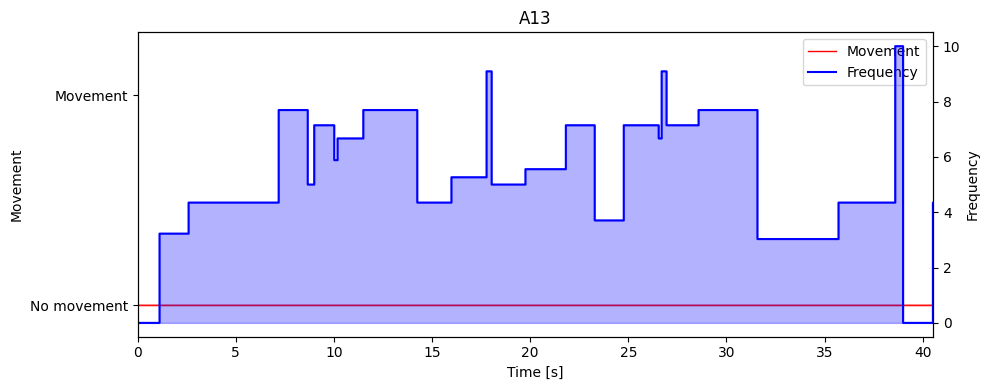

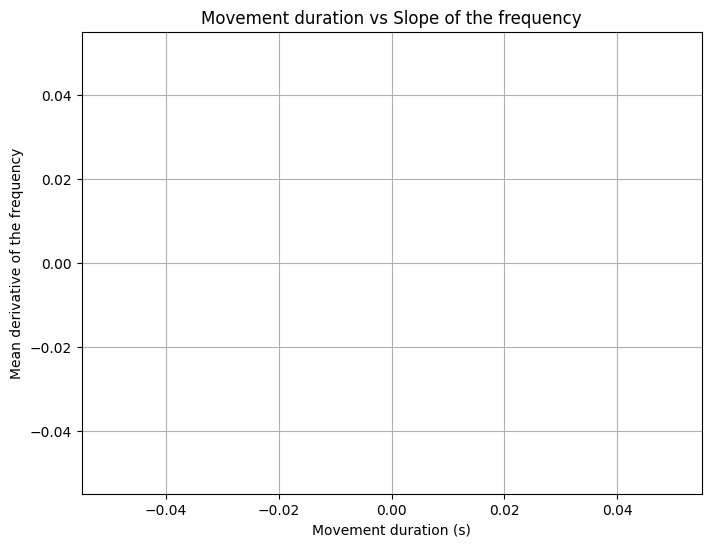

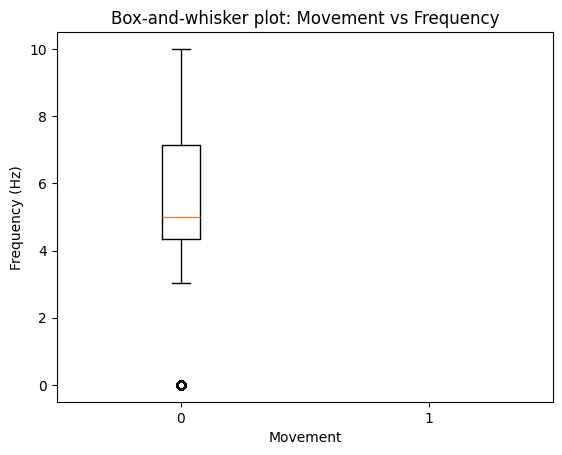

Processing: A14
✔ A14 → A14_cleaned.csv


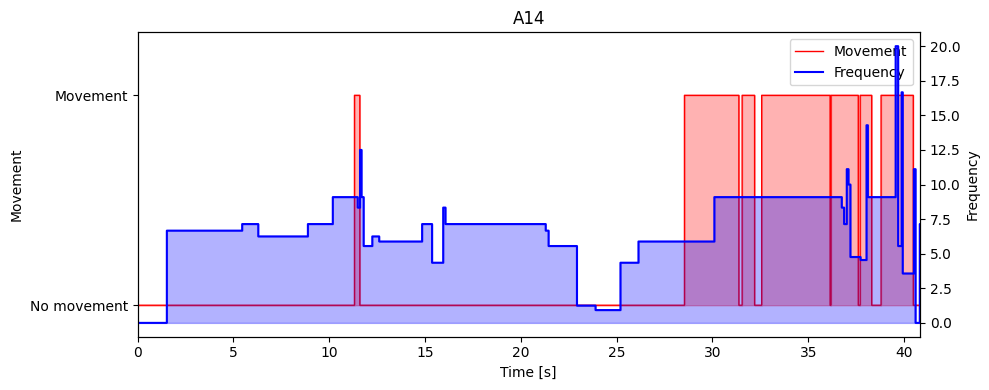

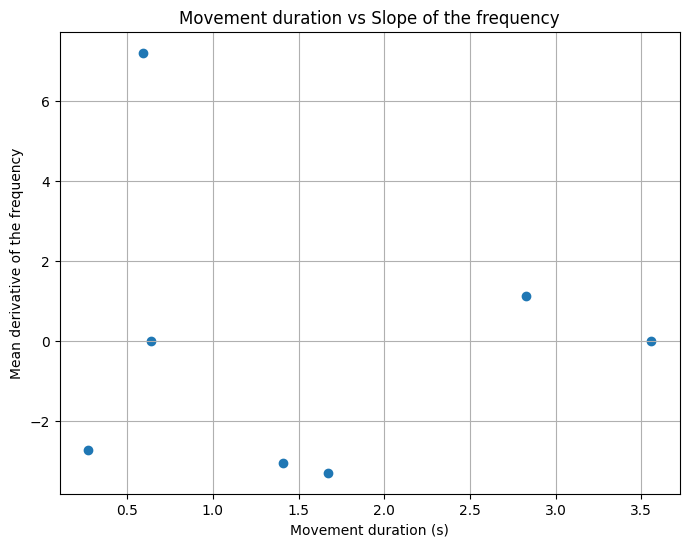

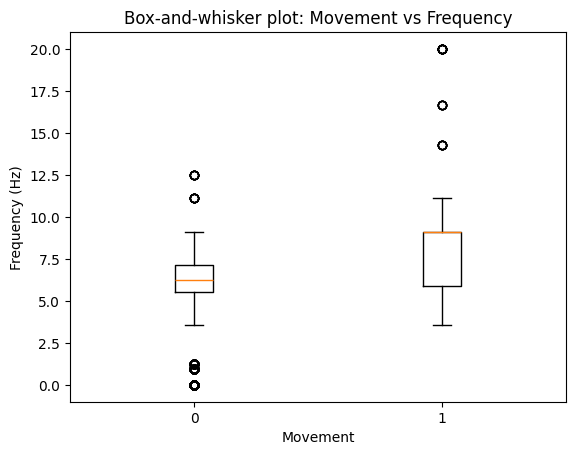

Processing: A15
✔ A15 → A15_cleaned.csv


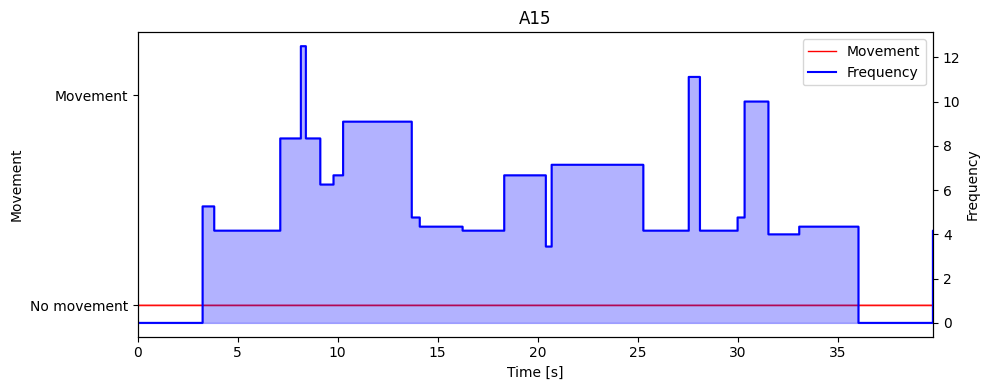

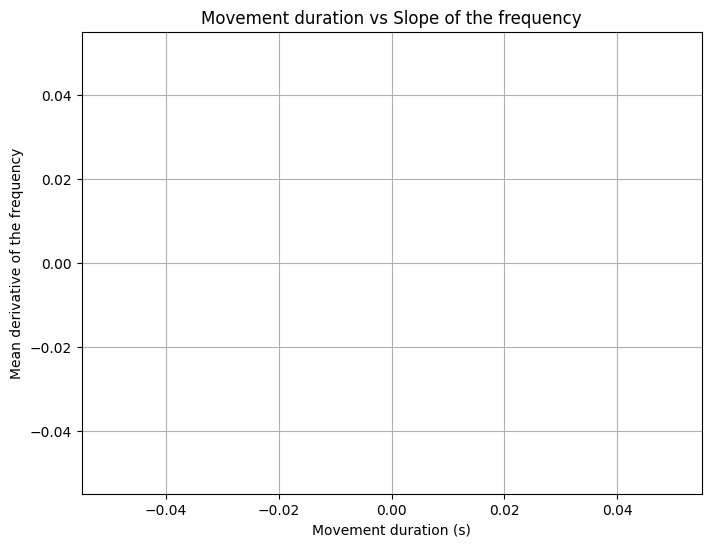

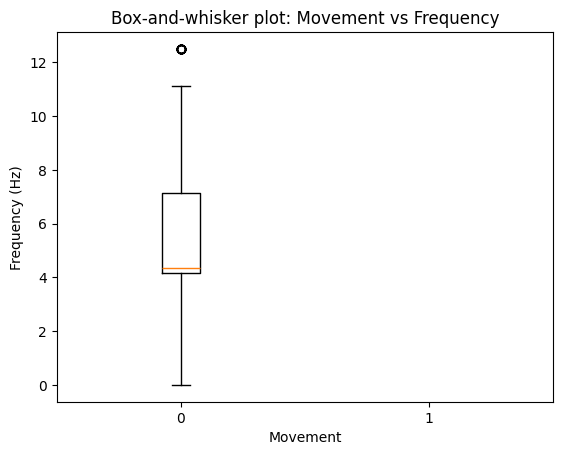

⚠️ No ID match for -movementTraceM09.mat
Processing: M4
✔ M4 → M4_cleaned.csv


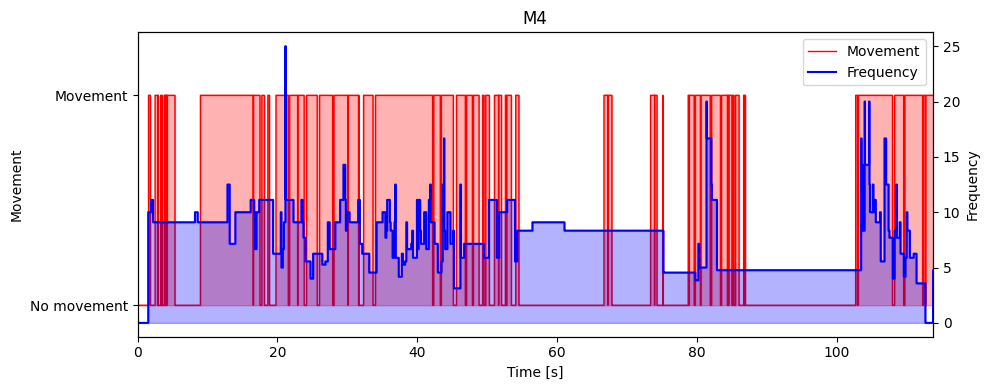

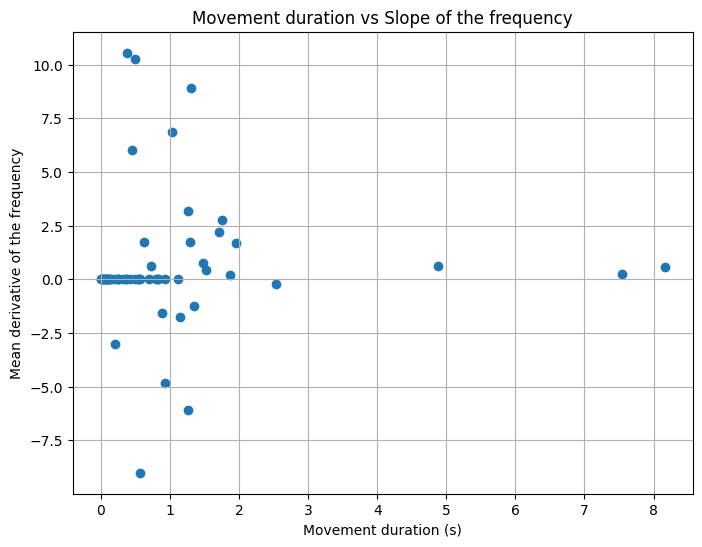

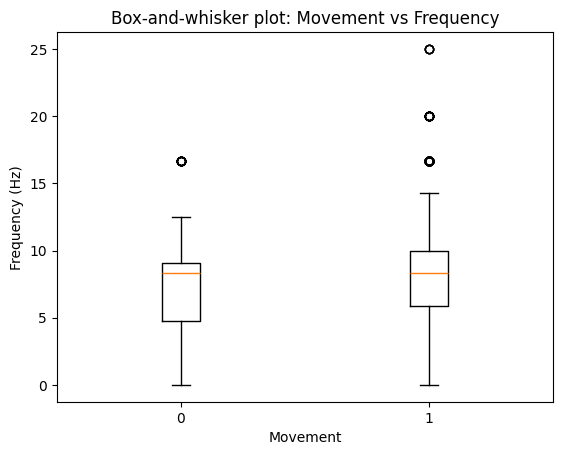

Processing: MI16
✔ MI16 → MI16_cleaned.csv


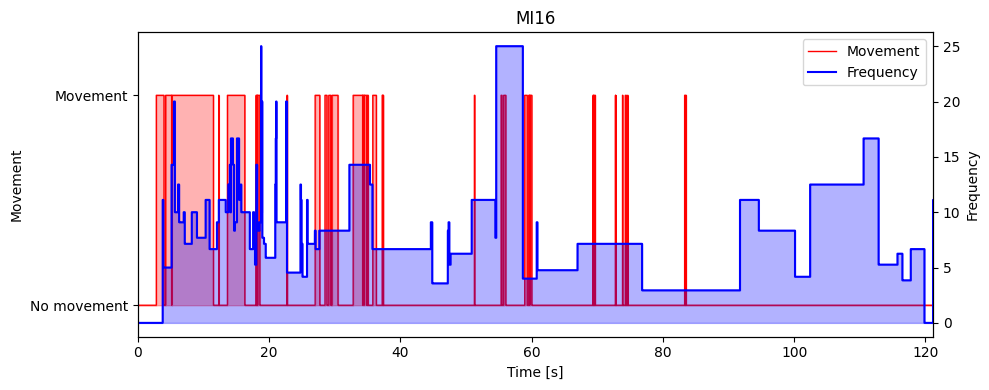

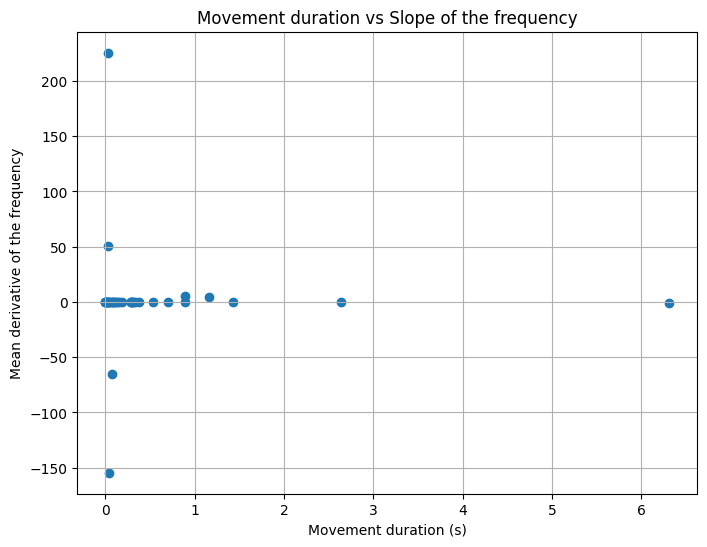

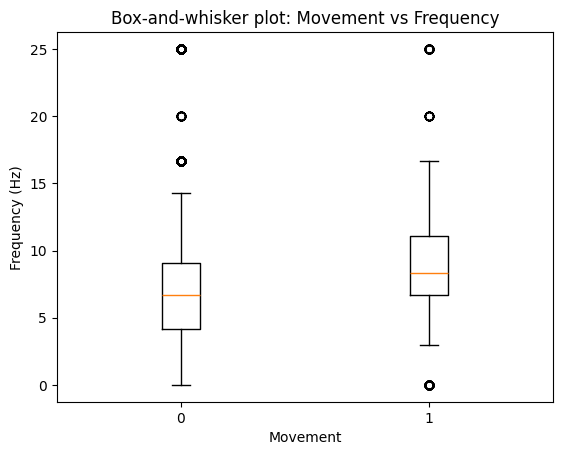

Processing: N1
✔ N1 → N10_cleaned.csv


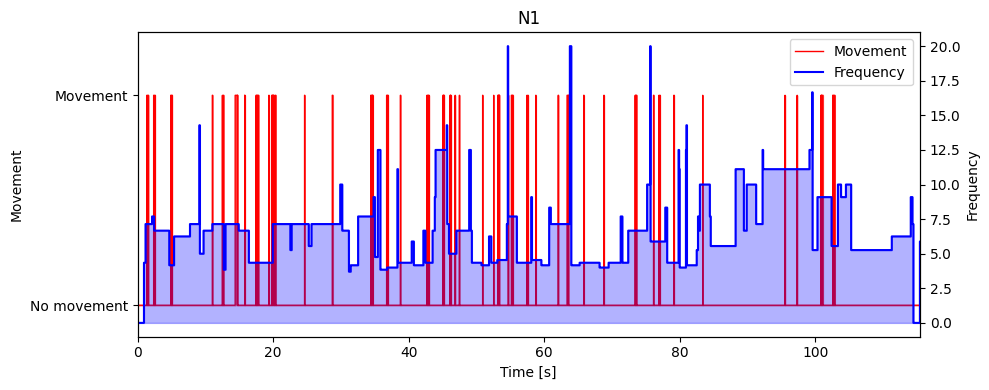

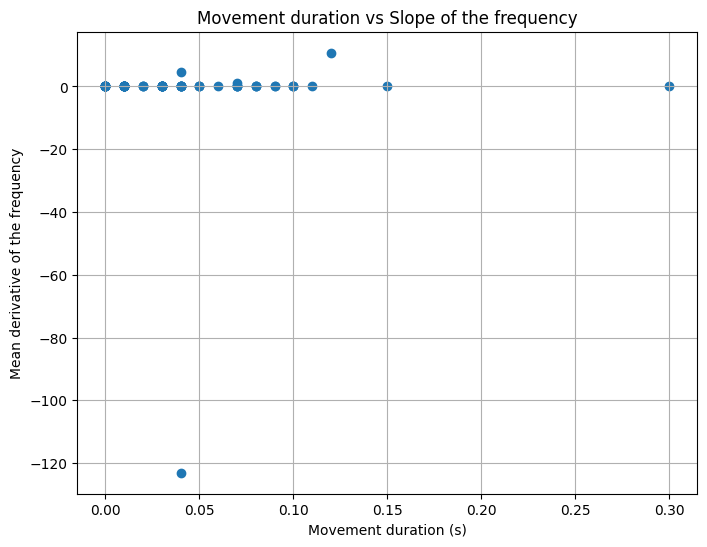

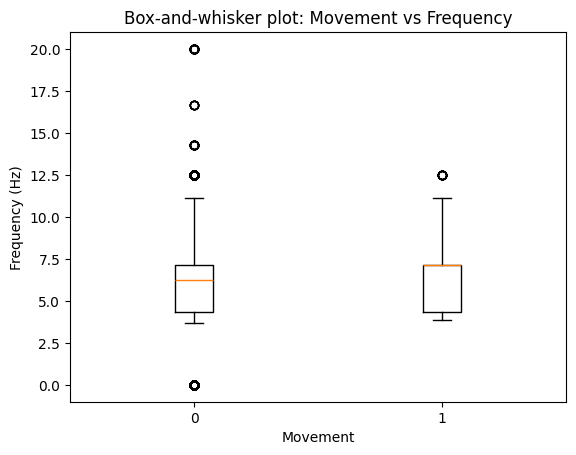

Processing: N10
✔ N10 → N10_cleaned.csv


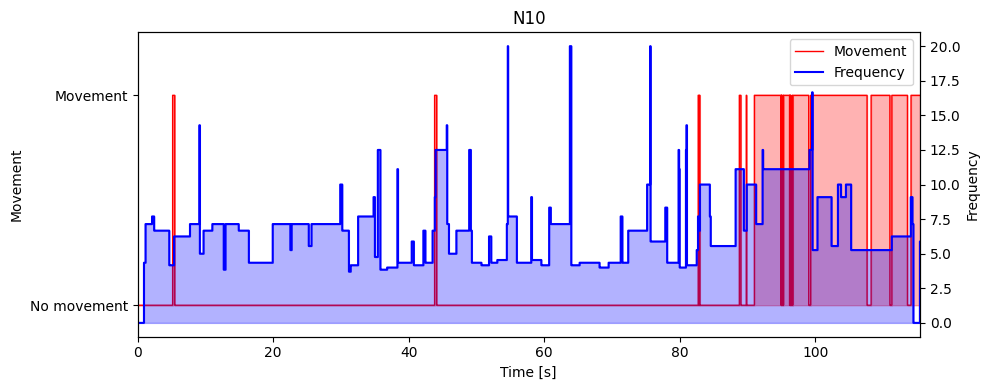

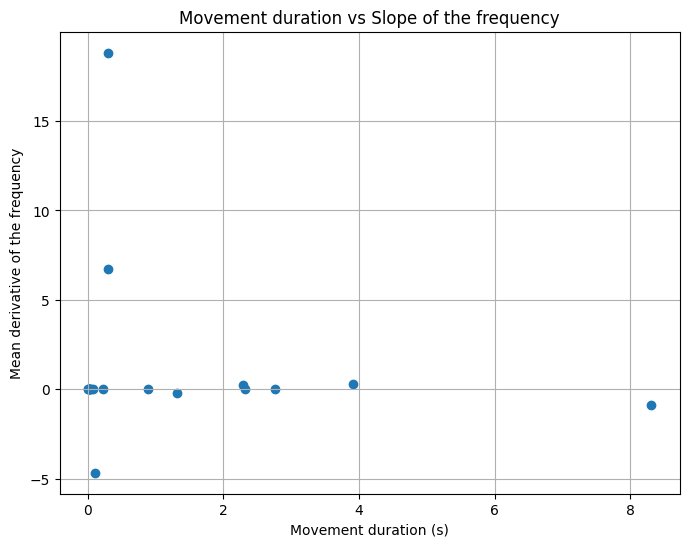

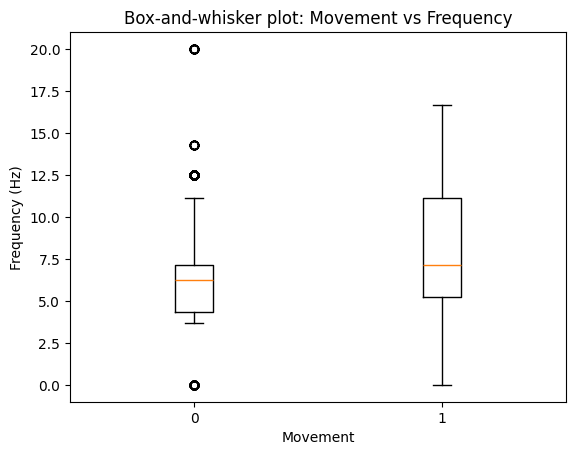

Processing: N11
✔ N11 → N11_cleaned.csv


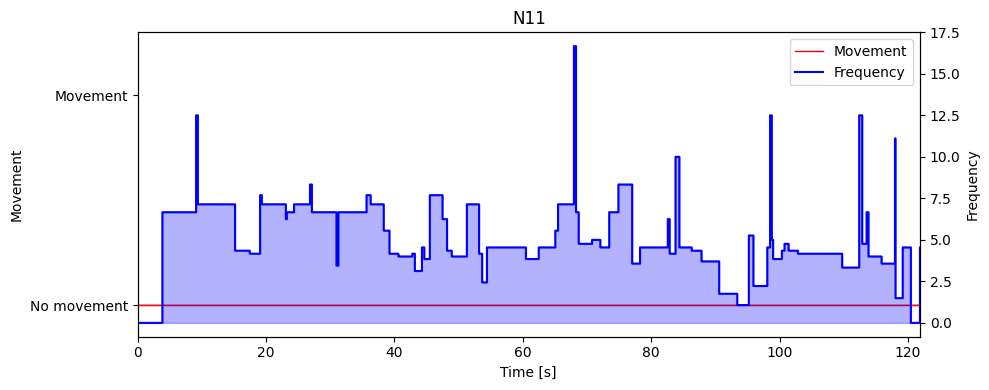

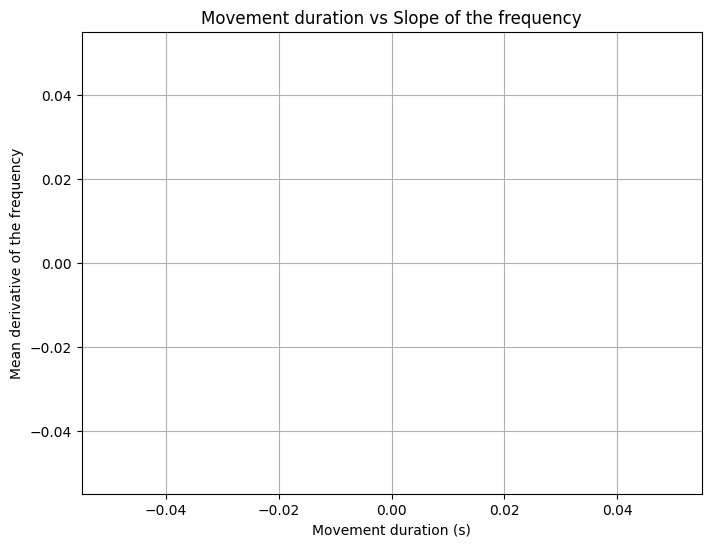

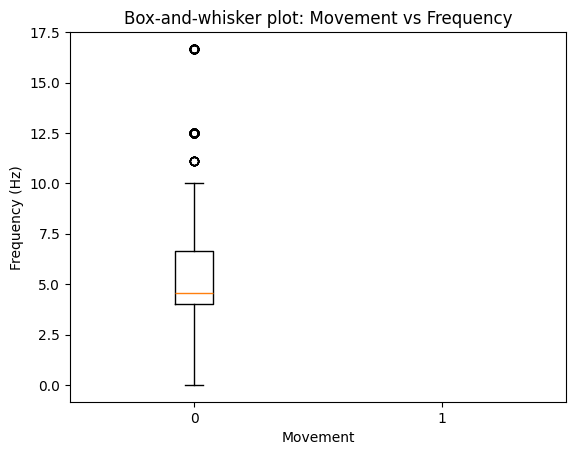

Processing: N2
✔ N2 → N2_cleaned.csv


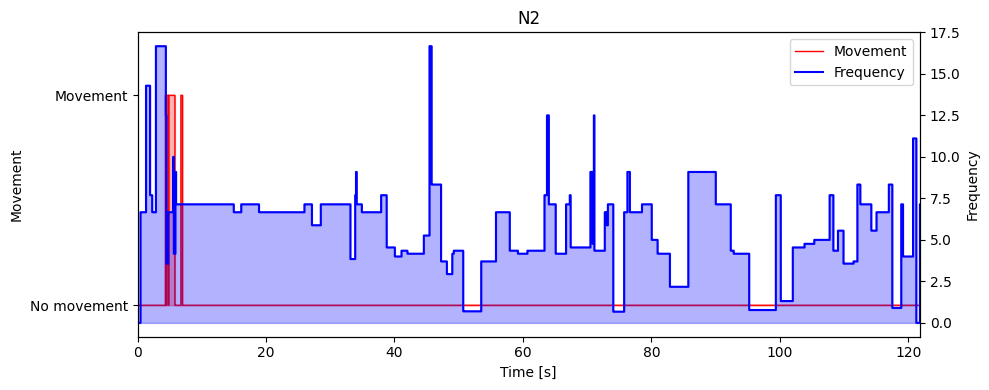

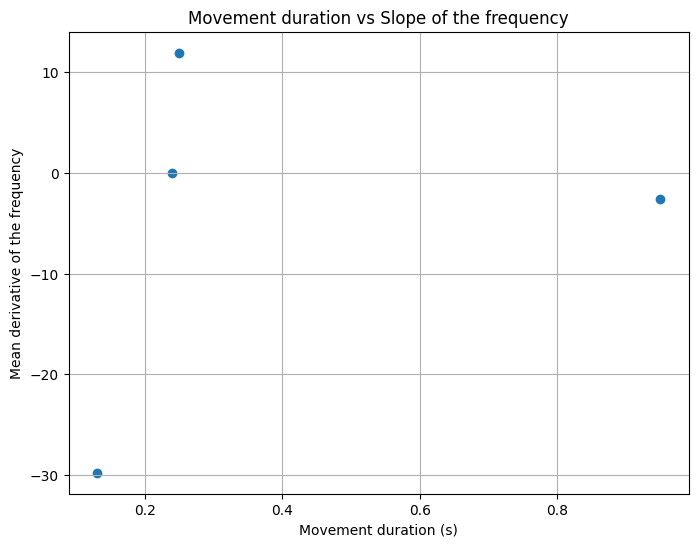

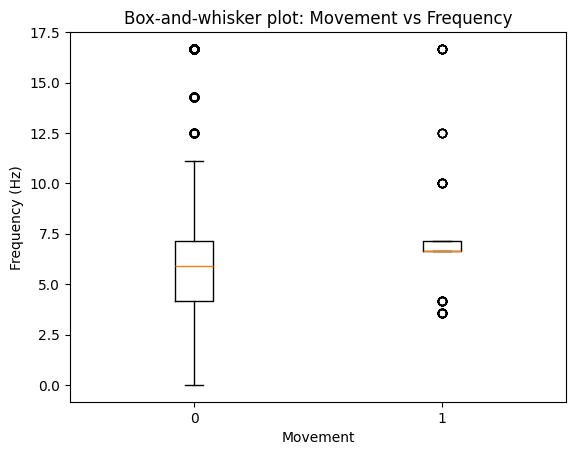

Processing: N3
✔ N3 → N3_cleaned.csv


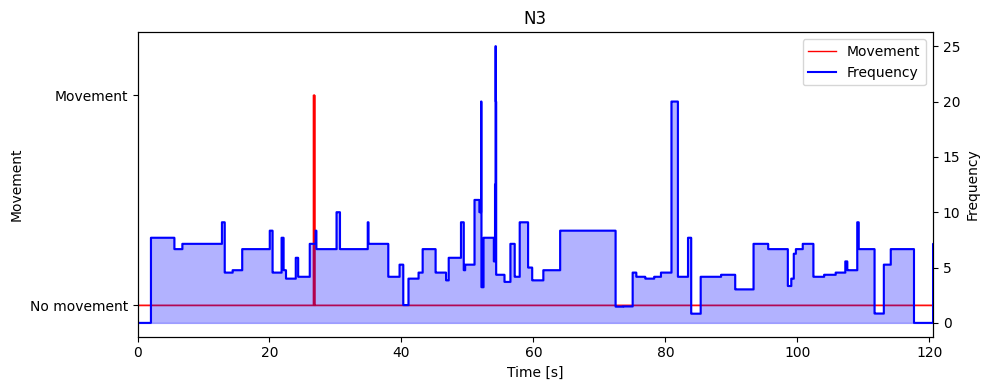

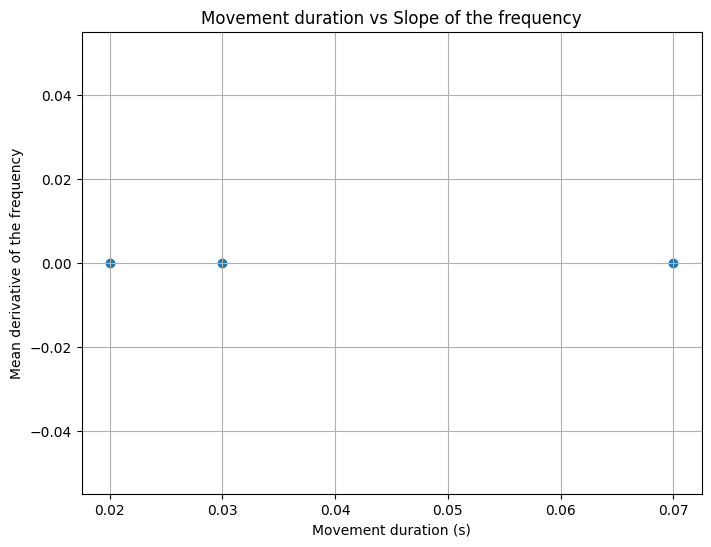

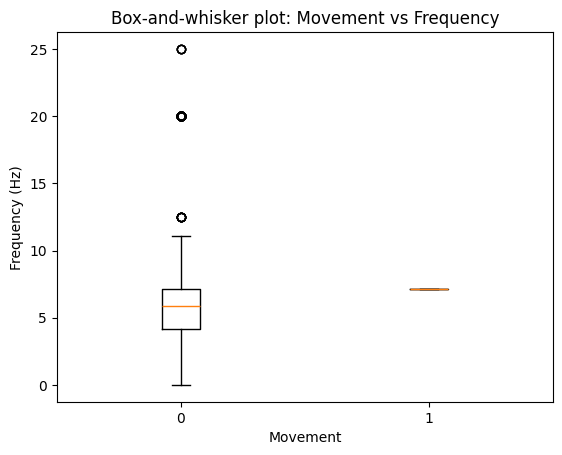

Processing: S17
✔ S17 → S17_cleaned.csv


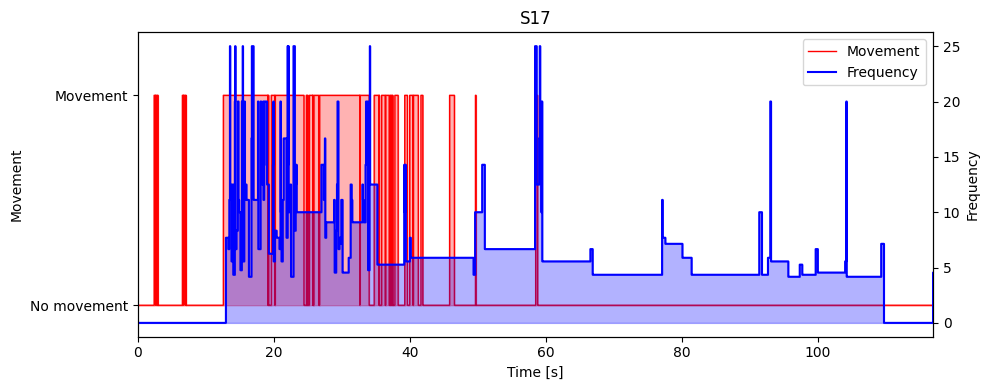

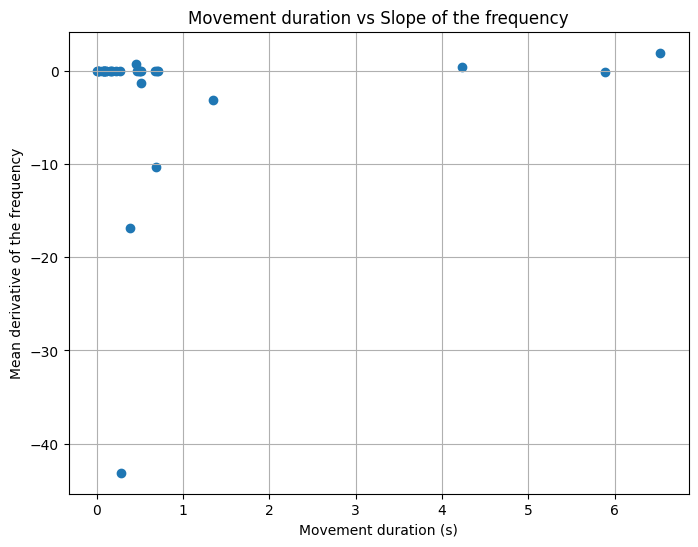

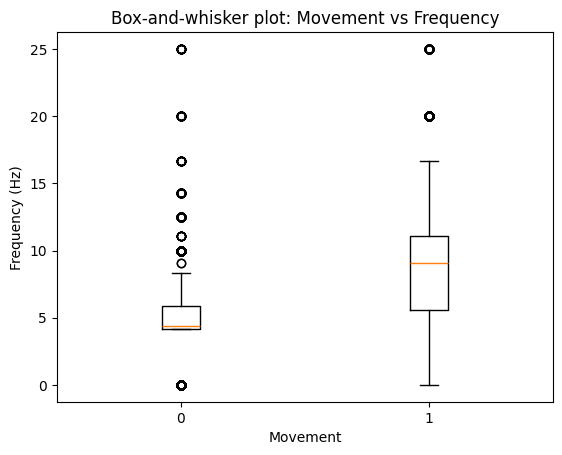

Processing: S18
✔ S18 → S18_cleaned.csv


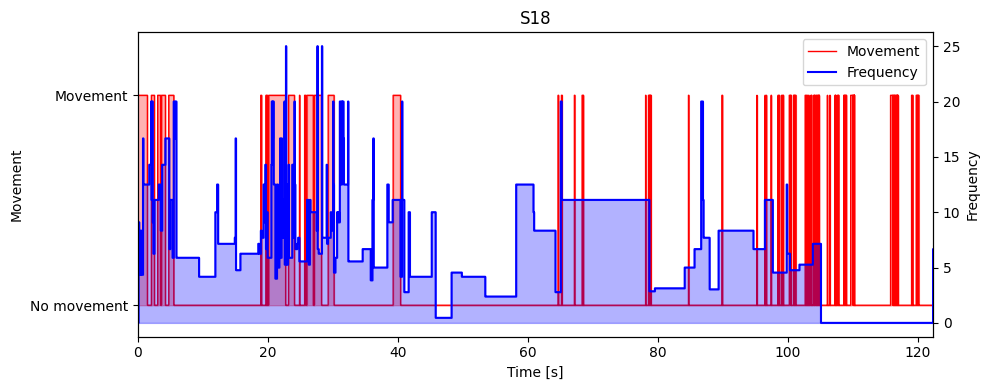

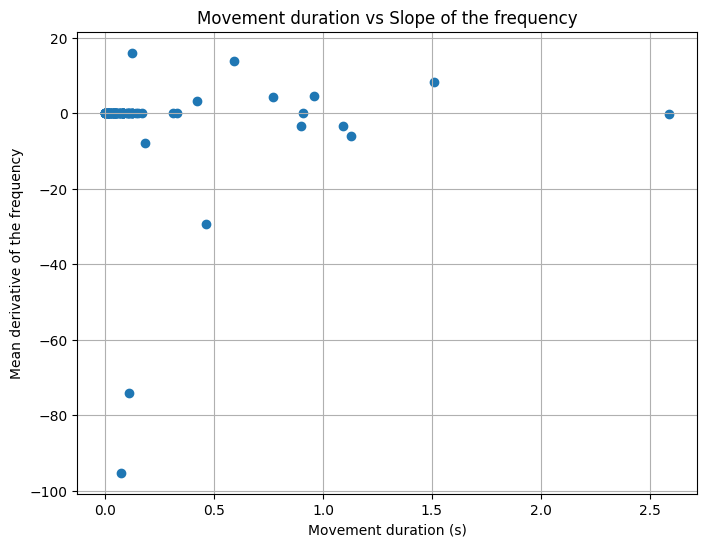

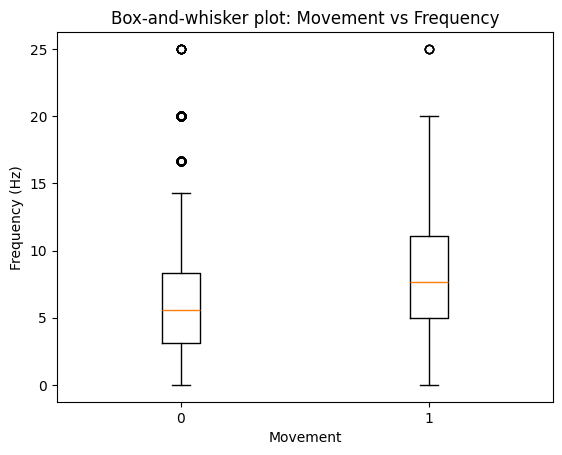

Processing: S5
✔ S5 → S5_cleaned.csv


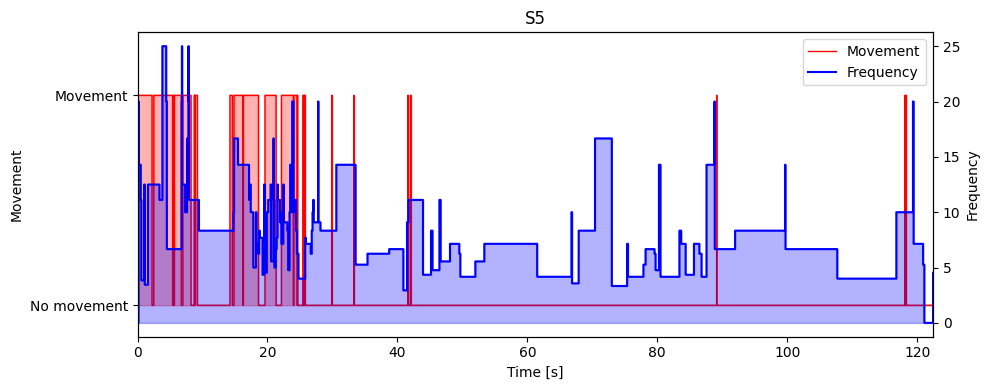

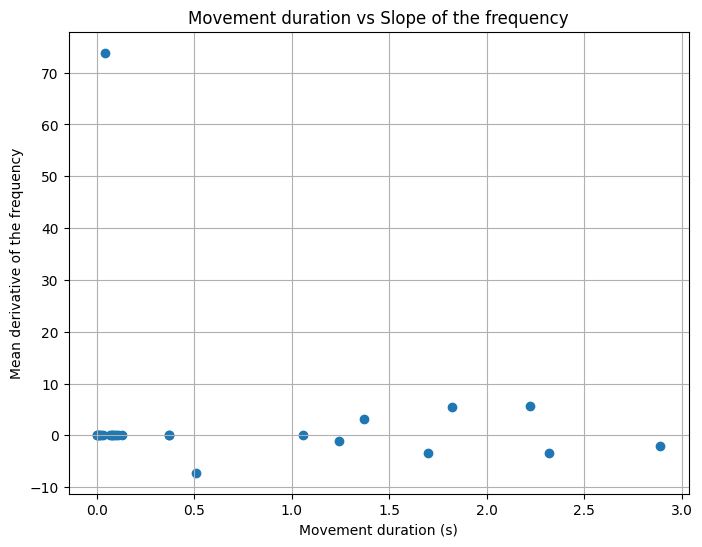

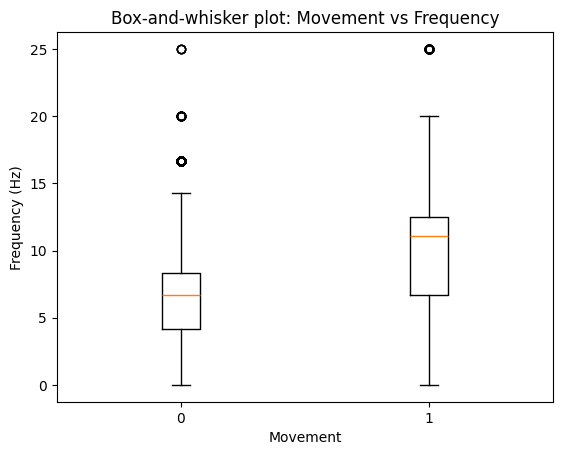

Processing: S6
✔ S6 → S6_cleaned.csv


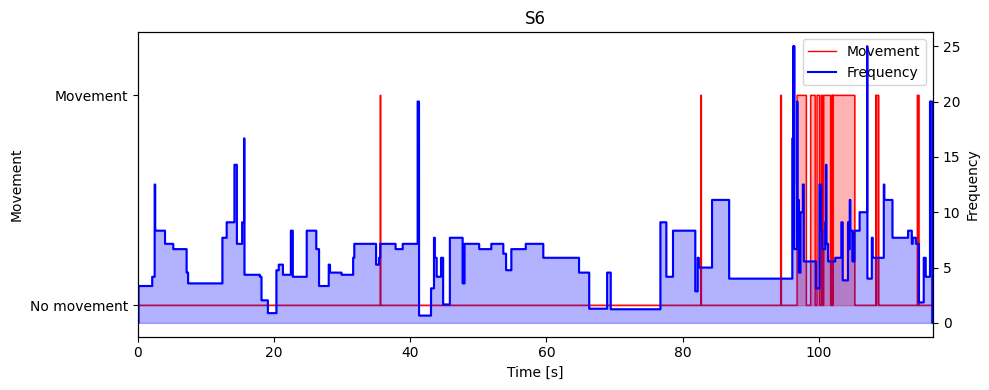

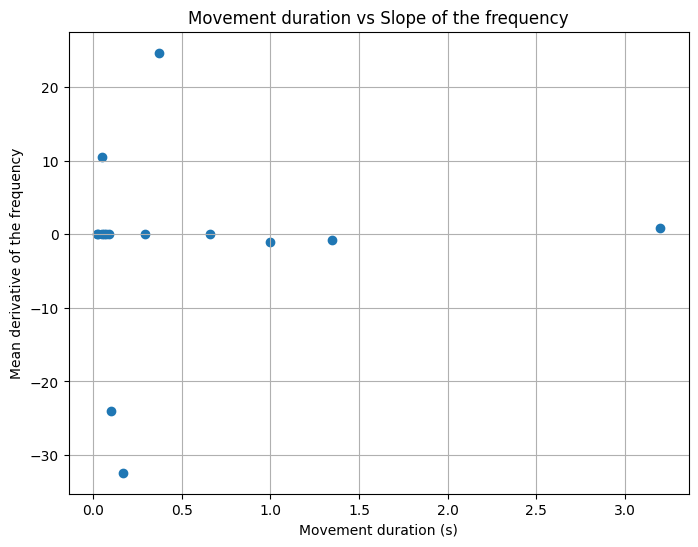

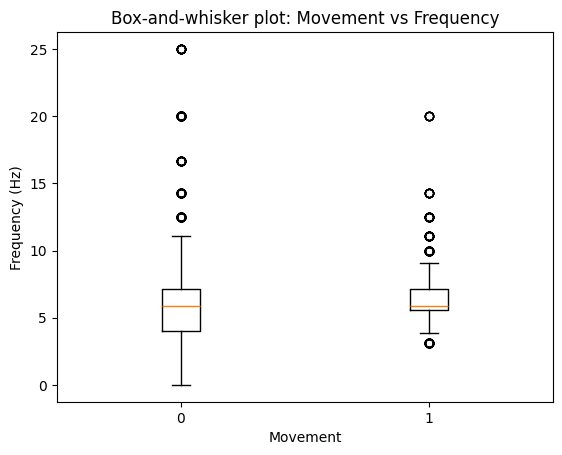

Processing: S8
✔ S8 → S8_cleaned.csv


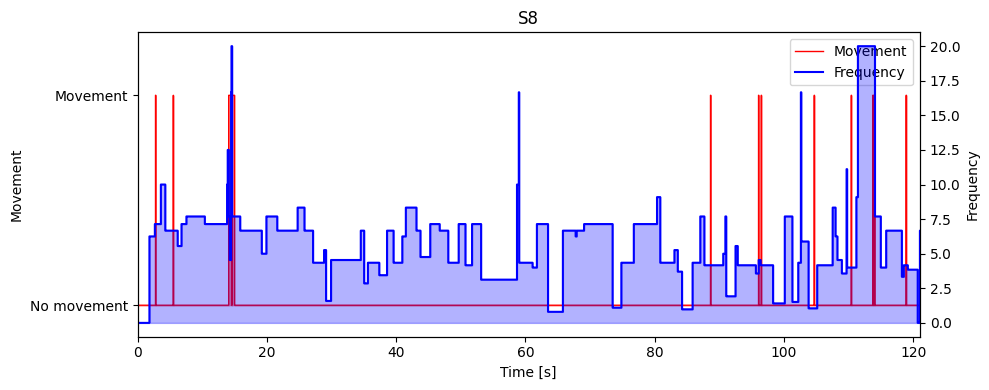

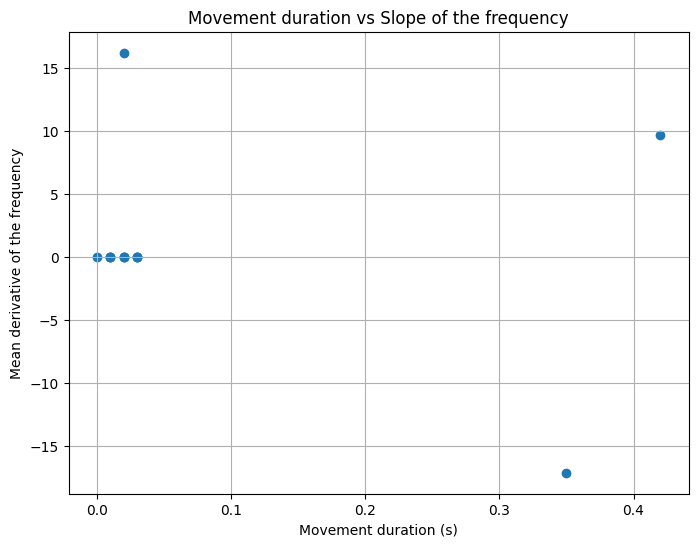

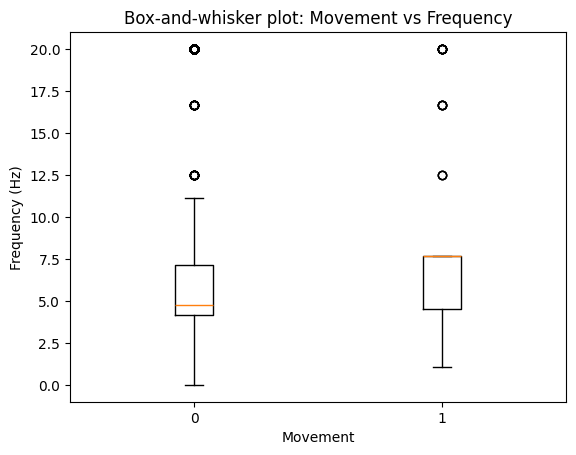

Processing: S7
✔ S7 → S7_cleaned.csv


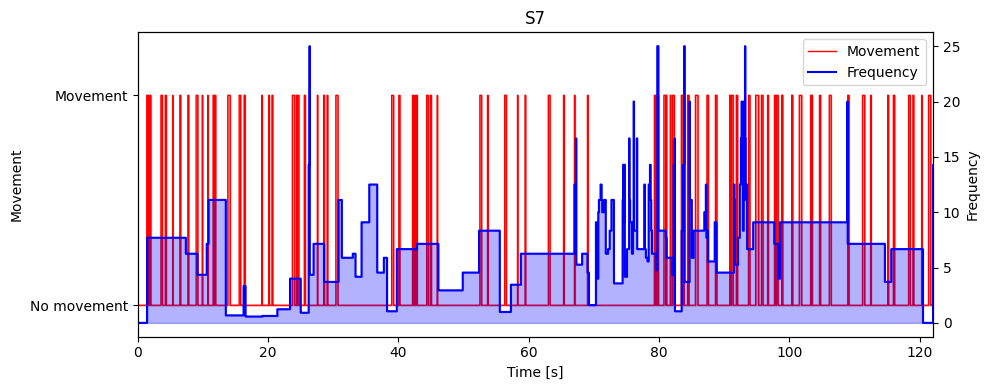

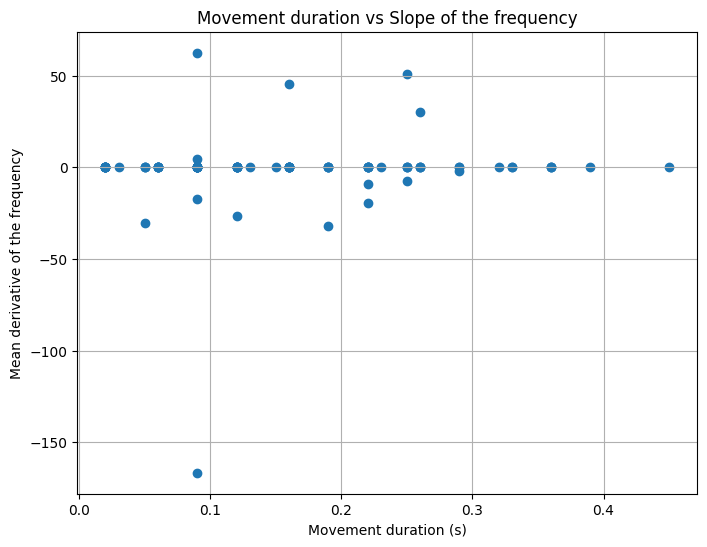

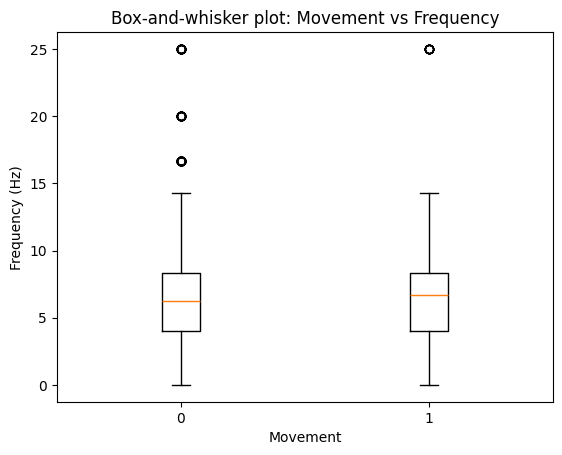


    ID      Corr_Biserial       P_Value    Effect_Size    Mean_Freq_Move    Mean_Freq_Stop    Mutual_Info    Best_Lag_s    Max_CCF
--  ----  ---------------  ------------  -------------  ----------------  ----------------  -------------  ------------  ---------
 0  A12             0.096   1.67898e-09           0.75               8.3              4.85          0.012         -1.96      0.316
 2  A14             0.408  3.05734e-163          0.525               8.2              5.83          0.299          0.75      0.451
 4  M4              0.193   6.74996e-96          0.238              7.94              6.86          0.181        -24.43       0.29
 5  MI16            0.131   1.82385e-47          0.309              9.33              7.53          0.106        -47.14      0.259
 6  N1              0.003      0.776507          0.086              6.53              6.49          0.017           -44      0.089
 7  N10             0.268  1.28612e-188          0.368              7.84          

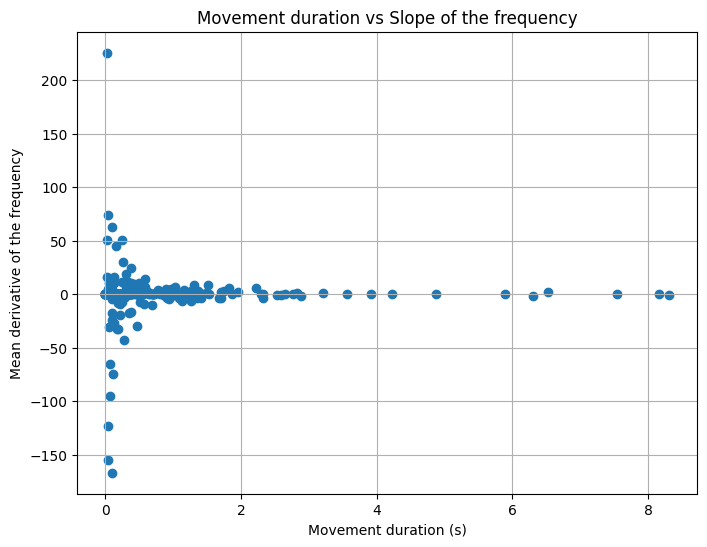

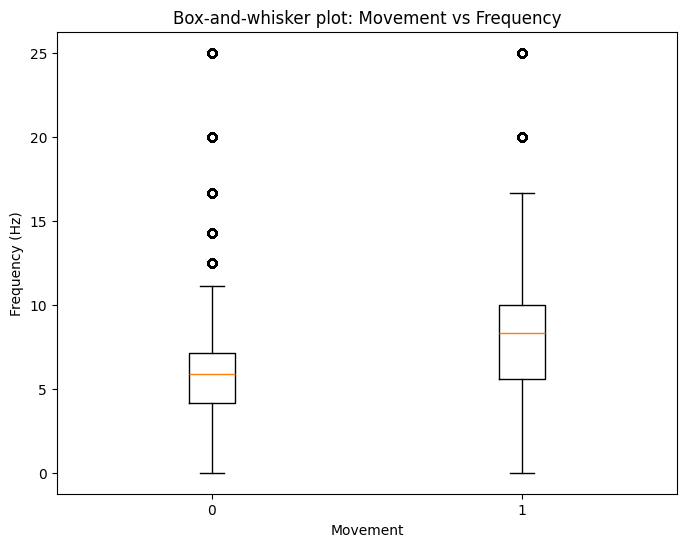

In [179]:
CLEANED_FOLDER = data_path
durations_vec = []
movements_vec = []
freq0_vec = []
freq1_vec = []

def load_movement(mat_path: Path):
    mat = scipy.io.loadmat(str(mat_path))
    mt = mat["movementTrace"]
    duration = float(mt["duration"][0, 0].item())
    movement = mt["movement"][0, 0].flatten().astype(float)
    time = np.linspace(0, duration, len(movement))
    return time, movement, duration



def get_frequency_for_id(subject_id, cleaned_folder):
    cleaned_folder = Path(cleaned_folder)
    pattern = str(cleaned_folder / f"*{subject_id}*_cleaned.csv")
    matches = glob.glob(pattern)

    if not matches:
        print(f"⚠️ No CSV found for {subject_id}")
        return None, None

    file = matches[0]
    print(f"✔ {subject_id} → {os.path.basename(file)}")

    result = process_video_whisking_only(file, whisker="w1b")
    Freq = result['frequency_hz']
    Time_f = result["frame"]/FPS

    return Time_f, Freq


def plot_movement(Time_f, Freq, time, movement, title: str):
    fig, ax1 = plt.subplots(figsize=(10, 4))

    ax1.step(time, movement, linewidth=1, label="Movement", color="red", where="post")
    ax1.fill_between(time, movement, color="red", alpha=0.3, step = "post")
    ax1.set_yticks([0, 1])
    ax1.set_yticklabels(["No movement", "Movement"])
    ax1.set_ylabel("Movement")
    ax1.set_xlabel("Time [s]")
    ax1.set_xlim(0, time[-1])
    ax1.set_ylim(-0.15, 1.3)

    # Frequency (only if available)
    if Time_f is not None and Freq is not None:        
        ax2 = ax1.twinx()
        ax2.step(Time_f, Freq, label="Frequency", color="blue", where = "pre")
        ax2.fill_between(Time_f, Freq, color="blue", alpha=0.3, step = "pre")
        ax2.set_ylabel("Frequency")

        # Combine legends
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2)
    else:
        ax1.legend()

    ax1.set_title(title)

    plt.tight_layout()
    plt.show()
    plt.close(fig)


def process_folder(folder: Path, cleaned_folder: Path, video_names):
    all_results = [] # Statistics dictionary
    
    if not folder.is_dir():
        print(f"Folder not found: {folder}")
        return

    mat_files = sorted(folder.glob("*.mat"))

    if not mat_files:
        print("No .mat files found")
        return

    print(f"Found {len(mat_files)} .mat files\n")

    for mat_path in mat_files:

        subject_id = None
        for vid in video_names:
            if vid in mat_path.stem:
                subject_id = vid
                break

        if subject_id is None:
            print(f"⚠️ No ID match for {mat_path.name}")
            continue

        print(f"Processing: {subject_id}")


        # Movement
        time, movement, duration = load_movement(mat_path)

        # Frequency (direct by ID)
        Time_f, Freq = get_frequency_for_id(subject_id, cleaned_folder)
        fs_movement = len(movement)/duration
        time = np.arange(len(movement)) / fs_movement
        f = interp1d(time, movement, kind='nearest', fill_value="extrapolate")
        movement_interp = f(Time_f.to_numpy())
        
        # Statistics:
        stats_data = get_stats_dict(subject_id, movement_interp, Freq)
        all_results.append(stats_data)
        
        
        # Plot
        plot_movement(Time_f.to_numpy(), Freq.to_numpy(), Time_f.to_numpy(), movement_interp, title=subject_id)
        try:
            durations, mean_slopes, freq0, freq1 = analyze_movement_frequency(Freq.to_numpy(), movement_interp, Time_f.to_numpy(), FPS)
        except ValueError:
            durations, mean_slopes = analyze_movement_frequency(Freq.to_numpy(), movement_interp, Time_f.to_numpy(), FPS)
            freq0 = None
            freq1 = None
        durations_vec.extend(durations)
        movements_vec.extend(mean_slopes)
        if freq1 is not None:
            freq0_vec.extend(freq0)
            freq1_vec.extend(freq1)
            
    # Create and show table statistics
    df_results = pd.DataFrame(all_results)
    
    # Order per ID
    df_results = df_results.sort_values("ID").reset_index(drop=True)
    
    return df_results
# Run
df_final = process_folder(FOLDER, CLEANED_FOLDER, video_names)

# Order and clean
df_final = df_final.dropna(subset=['Corr_Biserial'])

print("\n" + "="*85)
print(tabulate(df_final, headers='keys', tablefmt='simple', numalign="right"))
print("="*85)
print("Note: Negative Best_Lag_s indicates whisking preceedes movement.")

# --- PLOT DERIVATIVE ---
plt.figure(figsize=(8, 6))

plt.scatter(durations_vec, movements_vec)

plt.xlabel("Movement duration (s)")
plt.ylabel("Mean derivative of the frequency")
plt.title("Movement duration vs Slope of the frequency")

plt.grid(True)
plt.show()

# --- BOXPLOT ---
plt.figure(figsize=(8, 6))

plt.boxplot([freq0_vec, freq1_vec], tick_labels=[0, 1])
plt.xlabel('Movement')
plt.ylabel('Frequency (Hz)')
plt.title('Box-and-whisker plot: Movement vs Frequency')
plt.show()


### **17. Calcium ROIS**
This function generates a 3D plot per video of the ROI traces activity along time and at different depths of the S1 barrel cortex. You can also modify it to plot the Soma traces and the Neurite traces.

Found 22 subject folder(s)


Subject: A17
  Processing: -calciumTrace.mat
ROI traces shape: (52, 424)
Soma traces shape: (7, 424)
Neurite traces shape: (120, 424)


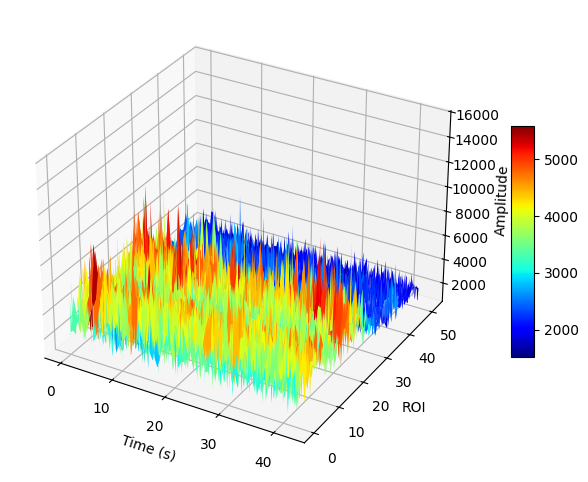


Subject: A18
  Processing: -calciumTrace.mat
ROI traces shape: (52, 424)
Soma traces shape: (7, 424)
Neurite traces shape: (120, 424)


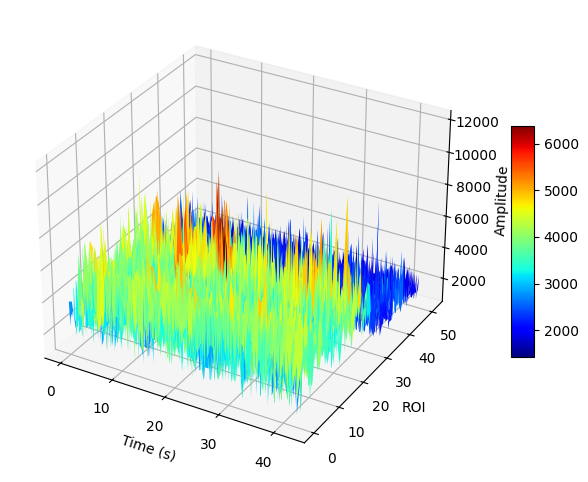


Subject: A19
  Processing: -calciumTrace.mat
ROI traces shape: (52, 424)
Soma traces shape: (7, 424)
Neurite traces shape: (120, 424)


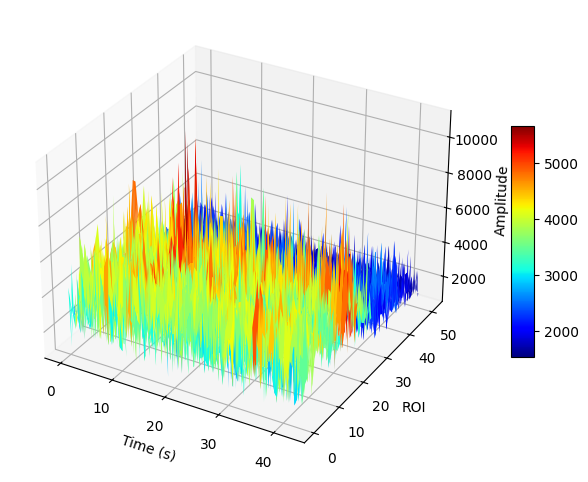


Subject: A20
  Processing: -calciumTrace.mat
ROI traces shape: (52, 424)
Soma traces shape: (7, 424)
Neurite traces shape: (120, 424)


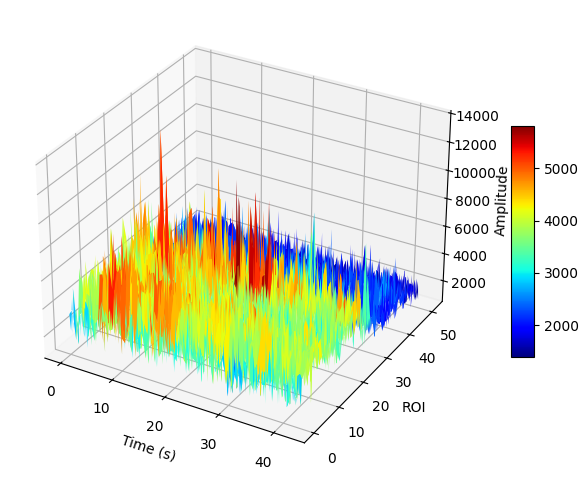


Subject: A21
  Processing: -calciumTrace.mat
ROI traces shape: (52, 636)
Soma traces shape: (7, 636)
Neurite traces shape: (120, 636)


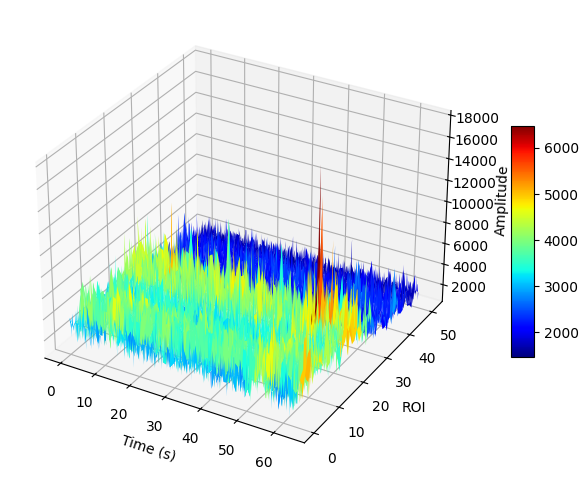


Subject: A22
  Processing: -calciumTrace.mat
ROI traces shape: (52, 636)
Soma traces shape: (7, 636)
Neurite traces shape: (120, 636)


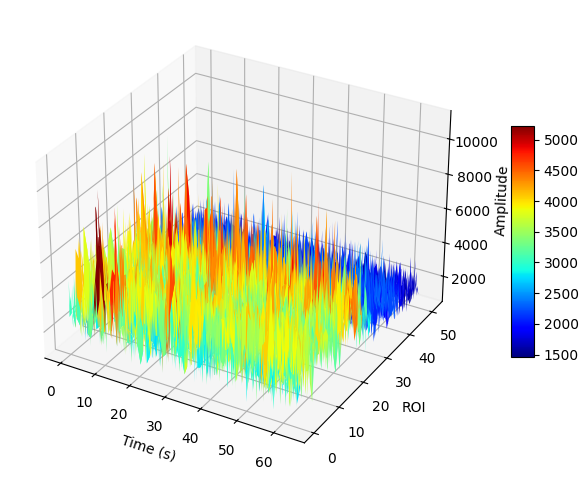


Subject: MI12
  Processing: -calciumTrace.mat
ROI traces shape: (52, 1273)
Soma traces shape: (7, 1273)
Neurite traces shape: (120, 1273)


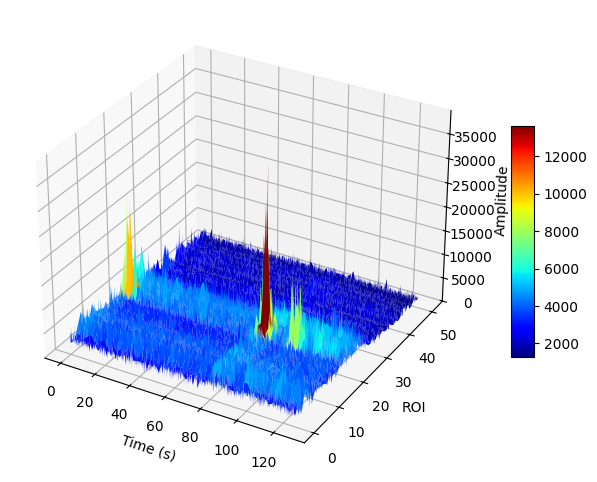


Subject: MI4
  Processing: -calciumTrace.mat
ROI traces shape: (52, 1273)
Soma traces shape: (7, 1273)
Neurite traces shape: (120, 1273)


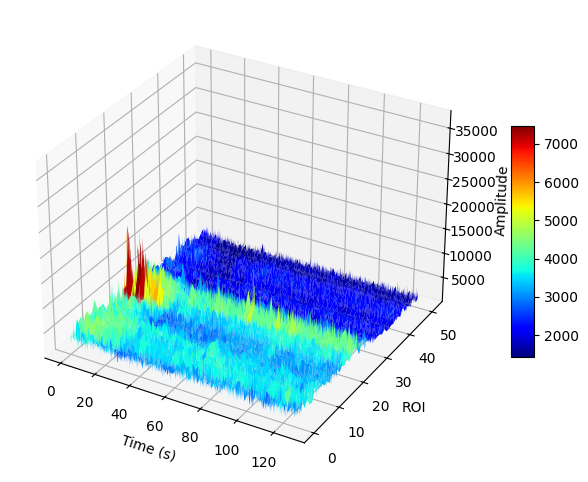


Subject: MO16
  Processing: -calciumTrace.mat
ROI traces shape: (52, 1273)
Soma traces shape: (7, 1273)
Neurite traces shape: (120, 1273)


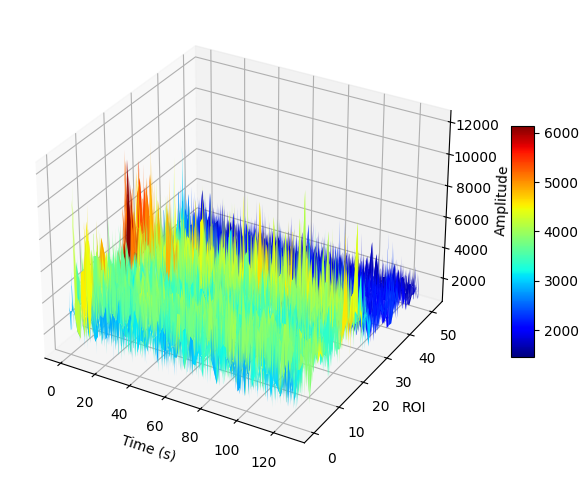


Subject: MO9
  Processing: -calciumTrace.mat
ROI traces shape: (52, 1273)
Soma traces shape: (7, 1273)
Neurite traces shape: (120, 1273)


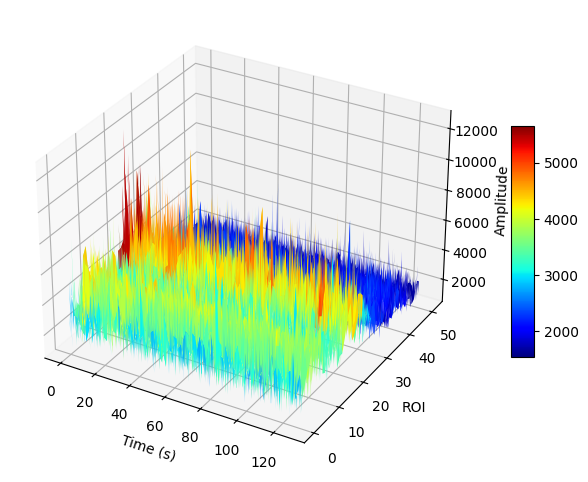


Subject: N1
  Processing: -calciumTrace.mat
ROI traces shape: (52, 1273)
Soma traces shape: (7, 1273)
Neurite traces shape: (120, 1273)


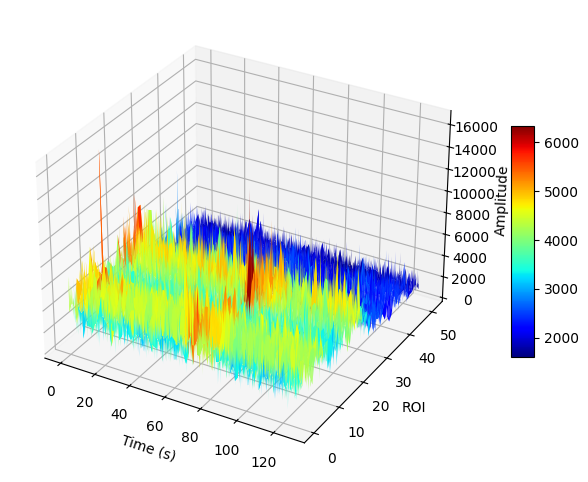


Subject: N10
  Processing: -calciumTrace.mat
ROI traces shape: (52, 1273)
Soma traces shape: (7, 1273)
Neurite traces shape: (120, 1273)


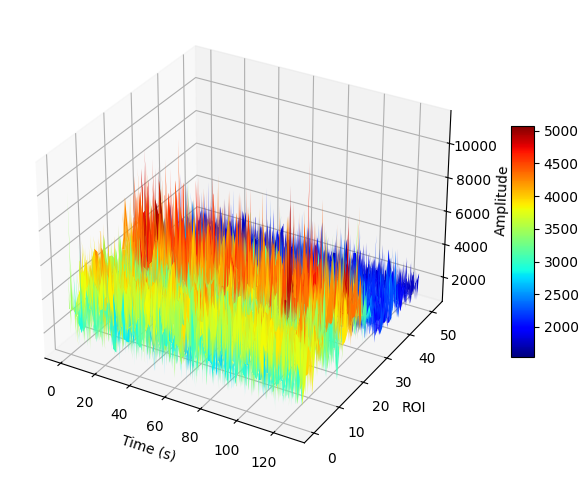


Subject: N11
  Processing: -calciumTrace.mat
ROI traces shape: (52, 1273)
Soma traces shape: (7, 1273)
Neurite traces shape: (120, 1273)


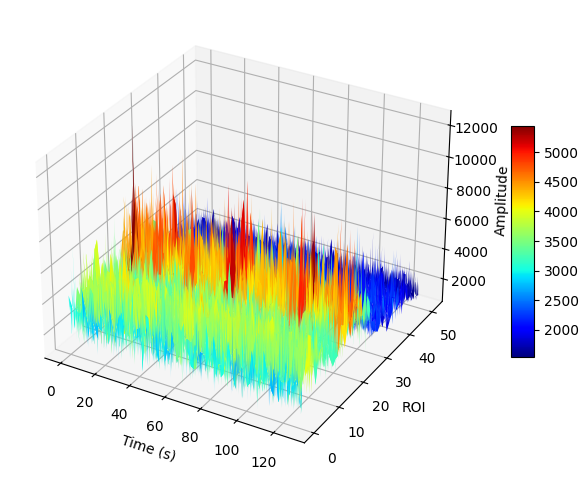


Subject: N2
  Processing: -calciumTrace.mat
ROI traces shape: (52, 1273)
Soma traces shape: (7, 1273)
Neurite traces shape: (120, 1273)


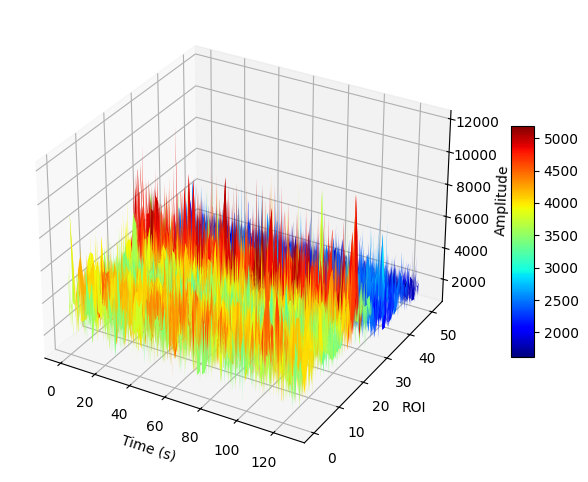


Subject: N3
  Processing: -calciumTrace.mat
ROI traces shape: (52, 1273)
Soma traces shape: (7, 1273)
Neurite traces shape: (120, 1273)


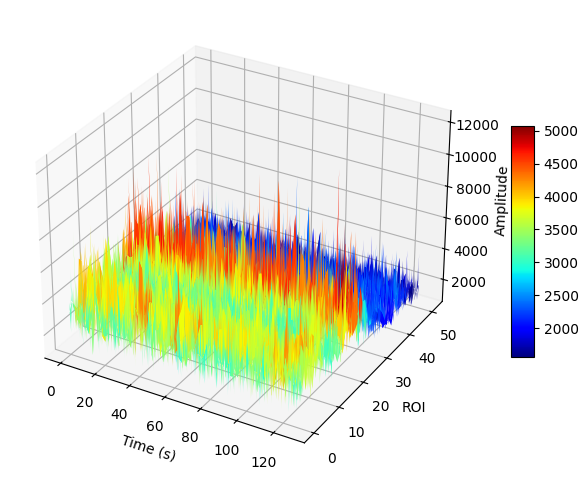


Subject: S13
  Processing: -calciumTrace.mat
ROI traces shape: (52, 1273)
Soma traces shape: (7, 1273)
Neurite traces shape: (120, 1273)


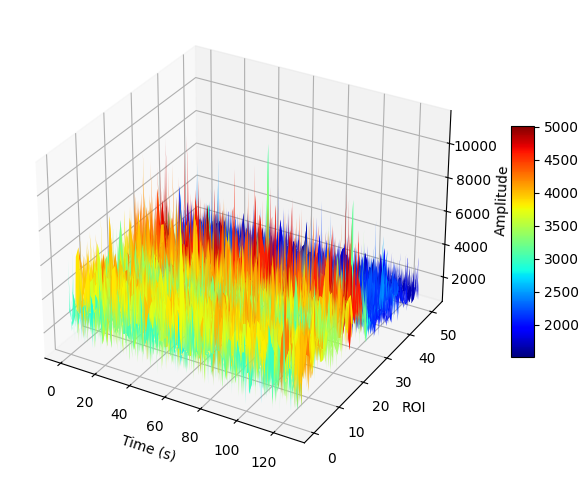


Subject: S14
  Processing: -calciumTrace.mat
ROI traces shape: (52, 1273)
Soma traces shape: (7, 1273)
Neurite traces shape: (120, 1273)


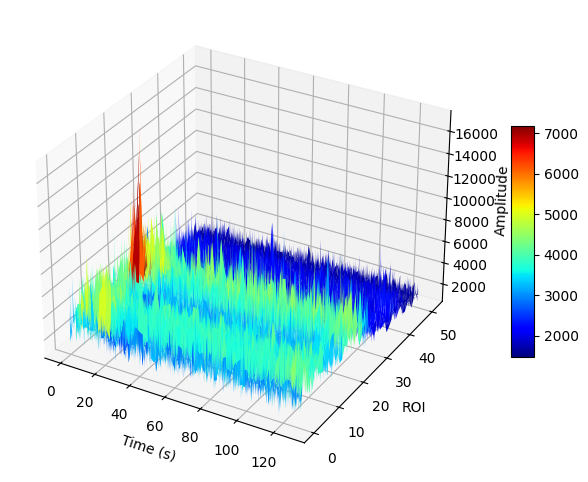


Subject: S15
  Processing: -calciumTrace.mat
ROI traces shape: (52, 1273)
Soma traces shape: (7, 1273)
Neurite traces shape: (120, 1273)


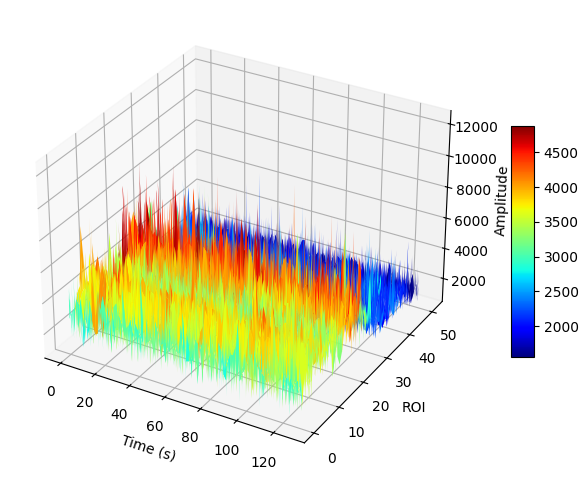


Subject: S5
  Processing: -calciumTrace.mat
ROI traces shape: (52, 1273)
Soma traces shape: (7, 1273)
Neurite traces shape: (120, 1273)


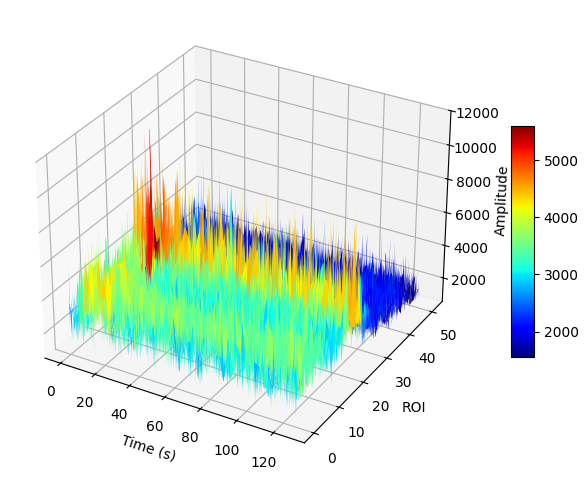


Subject: S6
  Processing: -calciumTrace.mat
ROI traces shape: (52, 1273)
Soma traces shape: (7, 1273)
Neurite traces shape: (120, 1273)


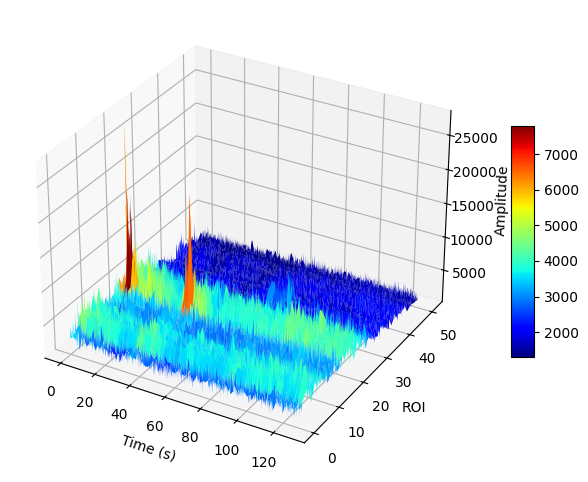


Subject: S7
  Processing: -calciumTrace.mat
ROI traces shape: (52, 1273)
Soma traces shape: (7, 1273)
Neurite traces shape: (120, 1273)


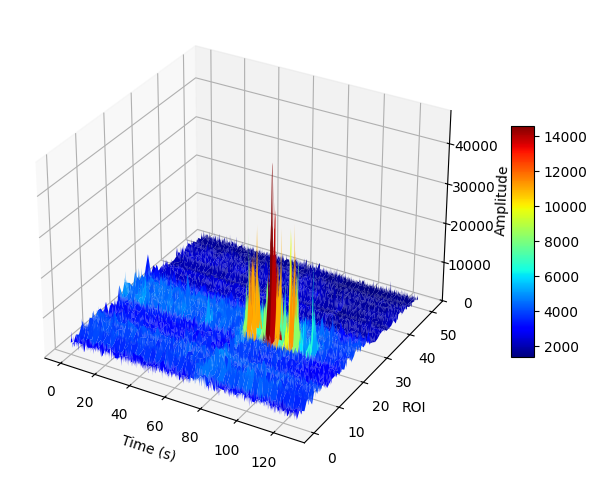


Subject: S8
  Processing: -calciumTrace.mat
ROI traces shape: (52, 1273)
Soma traces shape: (7, 1273)
Neurite traces shape: (120, 1273)


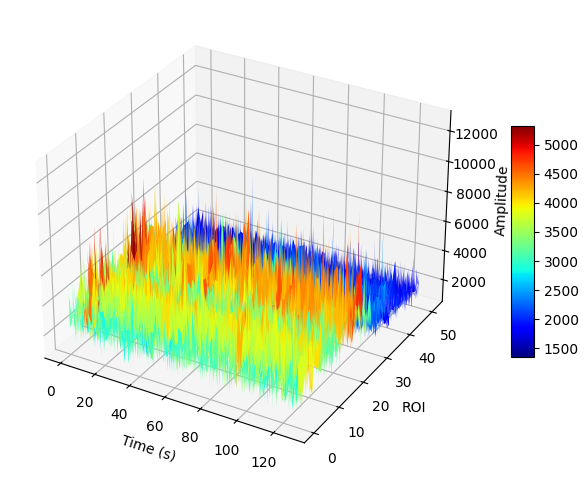


Finished processing.


In [178]:
def load_calcium(mat_path: Path):

    mat = scipy.io.loadmat(str(mat_path))

    # Access MATLAB structure
    ct = mat["calciumTrace"]

    # Extract ROI traces
    roi_traces = ct["ROItraces"][0, 0]

    # Optional additional fields you can plot
    soma_traces = ct["Somatraces"][0, 0]
    neurite_traces = ct["Neuritetraces"][0, 0]

    return roi_traces, soma_traces, neurite_traces

# Check folder exists
if not FOLDER_Ca.is_dir():
    print(f"Folder not found: {FOLDER_Ca}")
    print("Please update the FOLDER path at the top of the script.")

else:
    
    # Iterate through each subject folder
    subject_folders = [f for f in FOLDER_Ca.iterdir() if f.is_dir()]
    
    print(f"Found {len(subject_folders)} subject folder(s)\n")
    
    errors = []

    for subject_folder in subject_folders:
        
        print(f"\nSubject: {subject_folder.name}")
        
        # Search for the calciumTrace.mat inside this subject folder
        mat_files = list(subject_folder.glob("*calciumTrace.mat"))
        
        if not mat_files:
            print("  No calciumTrace.mat file found")
            continue
        
        # Only one file per subject
        mat_path = mat_files[0]
        
        try:
            print(f"  Processing: {mat_path.name}")
            
            roi_traces, soma_traces, neurite_traces = load_calcium(mat_path)
            print("ROI traces shape:", roi_traces.shape)
            print("Soma traces shape:", soma_traces.shape)
            print("Neurite traces shape:", neurite_traces.shape)
            
            
            n_rois, n_timepoints = roi_traces.shape

            # Time vector (assuming uniform sampling)
            time = np.linspace(0, n_timepoints/10, n_timepoints)

            # Create meshgrid
            T, R = np.meshgrid(time, np.arange(n_rois))

            # Z = amplitude
            Z = roi_traces

            # Plot
            fig = plt.figure(figsize=(10, 6))
            ax = fig.add_subplot(111, projection='3d')

            surf = ax.plot_surface(T, R, Z, cmap='jet', linewidth=0, antialiased=True)

            # Labels
            ax.set_xlabel('Time (s)')
            ax.set_ylabel('ROI')
            ax.set_zlabel('Amplitude')

            # Colorbar
            fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

            plt.show()
            
        except Exception as e:
            print(f"  ERROR: {e}")
            errors.append((subject_folder.name, str(e)))

    print("\nFinished processing.")

    if errors:
        print("\nErrors:")
        for subj, err in errors:
            print(f"  {subj}: {err}")